<a href="https://colab.research.google.com/github/datascience-uniandes/hypothesis-testing-tutorial/blob/master/business-case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Case

MINE-4101: Applied Data Science
Universidad de los Andes

**Dataset:** Airbnb Listings - Mexico City, Distrito Federal, Mexico [[dataset](http://insideairbnb.com/get-the-data/) | [dictionary](https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?usp=sharing)]. This dataset comprises information about Airbnb property listings in Mexico City. Each property includes attributes such as neighborhood, property type, price per night, number of reviews, review scores, availability, amenities, and more.

**Two facts that every number below depends on, and that are easy to leave implicit:** prices are in **Mexican pesos (MXN)**, not dollars — a median listing asks about 920 MXN (roughly 50 USD) per night — and the data is a single snapshot scraped between **27 June and 3 July 2023**. Neither is recoverable from the numbers themselves, so both are stated here and carried through every result.

**Business Context:** Property Investment and Vacation Rental Strategy. You are a consultant for individuals or firms looking to invest in properties for Airbnb rentals. They want to identify the most lucrative neighborhoods, optimal pricing strategies, and understand the factors that contribute to positive reviews and frequent bookings. <span style="color: red;">Since you currently only have a sample of all the properties listed in the city, you must ensure that the insights you extract from your analysis can be generalized to the entire set of properties.</span>

Last update: September, 2026

## How to read this notebook

Four habits are enforced throughout, and they are the actual content of the tutorial:

1. **Report the estimate and its interval before the p-value.** The p-value answers "is the difference distinguishable from zero?". The interval answers "how big might it be?" — which is the question a business decision needs.
2. **Verify assumptions instead of asserting them.** Every test rests on a model. We check the two that matter (independence and the sampling distribution) with resampling, rather than with a pre-test on the raw variable.
3. **Name the estimand before choosing the test.** Which quantity, for which population, on which date? Most analyses that mislead are not miscalculated — they answer a question adjacent to the one that was asked.
4. **State the decision threshold before looking at the result.** "Statistically significant" is not a business criterion. A threshold defined in advance turns an unanswerable question ("what is the magnitude?") into an answerable one ("is the magnitude past the line?").

**What to expect from the checks.** Two of the three assumption checks below come back clean. That is the normal outcome, and it is precisely why they are worth running: a check earns its place when you do not know the answer in advance, not only when you expect trouble. Read each one for what it licenses you to claim afterwards.

**Every result carries its own definition.** Each test prints the quantity, units, population and time frame it refers to, because a number without those four things cannot be checked, compared, or safely quoted. Those definitions live in one registry, introduced below.

**What we are estimating (the estimand).** The difference in *mean advertised nightly price* between two neighborhoods, among listings that an investor could plausibly buy and operate, as advertised on the date the dataset was scraped. Note what this is not: it is not the transacted price, not revenue, and not return on investment. Occupancy, cleaning fees and minimum-stay rules are not in this figure.

## The estimand ladder: what was asked, what we can measure, what we will estimate

The brief asks which neighborhoods are **most lucrative**. Nothing in this dataset measures that. Before running any test it is worth writing down the distance between the question and the data, because every rung of this ladder is a place where a conclusion can quietly change meaning.

| Rung | Quantity | Present in this dataset? |
|---|---|---|
| What the client wants | **Return on investment** — profit per unit of capital deployed | **No.** Acquisition price, financing, taxes and refurbishment are absent entirely. |
| ↓ | **Profit** — revenue minus operating costs | **No.** Cleaning, management fees, platform commission and maintenance are absent. |
| ↓ | **Revenue** — nightly price × nights actually booked | **Approximately.** Bookings are not recorded, but two independent proxies can be built from reviews and from availability. |
| ↓ | **Advertised nightly price** | **Yes, measured directly.** |

This notebook estimates the bottom rung first, because it is the only one available without assumptions, and then climbs one rung to revenue, where the business question actually lives. **The two rungs do not give the same answer**, and that gap is the central lesson of Question 1.

Two rules follow:

1. **Name the rung in every claim.** "Miguel Hidalgo is better" is not a finding. "Miguel Hidalgo has a higher mean advertised nightly price, in MXN per night, among investable listings, as advertised in late June 2023" is. The registry below turns that discipline into code.
2. **A proxy inherits its assumptions.** Climbing to revenue requires assuming a review rate and a stay length. Those assumptions are named, varied and checked below — never hidden inside a variable name.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, bootstrap

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 100
rng = np.random.default_rng(RANDOM_STATE)

# The share of the market we pretend to observe. Everything downstream depends on
# it, and Part E varies it deliberately -- so it is a named constant, not a
# literal buried in the call below.
SAMPLE_FRAC = 0.02

### The estimand registry

The ladder above is prose. This is the same thing as code, and it exists to make one specific mistake impossible.

Every quantity this notebook tests is registered below with four attributes: **what** is being measured, in **which units**, over **which population**, at **which moment**. The reporting helpers look estimands up here, so a test whose target has not been defined cannot be reported at all — it raises an error instead.

That is stricter than it sounds, and deliberately so. Notice how much of this is invisible in the numbers themselves: a difference of `573` is meaningless without *MXN per night*, over *investable listings with the luxury tail trimmed*, *as advertised in late June 2023*. Every one of those clauses narrows what may legitimately be claimed, and all of them vanish the moment someone copies the figure into a slide.

In [3]:
CURRENCY = "MXN"
SCRAPE_WINDOW = "27 Jun - 3 Jul 2023"

INVESTABLE = "investable listings (entire homes + private rooms; hotel and shared rooms excluded; per-neighborhood luxury tail trimmed)"
UNTRIMMED = "investable listings, luxury tail RETAINED"
ALL_ROOMS = "all room types, rare ones collapsed into 'Other'"
EVERY_LISTING = "every listing: all room types, no price trim, all neighborhoods"

# What each test is trying to measure. Adding a row here is a deliberate act:
# it is the moment you decide what a number will be allowed to mean.
ESTIMANDS = {
    "price": {
        "column": "price", "label": "Nightly price",
        "quantity": "Mean advertised nightly price",
        "units": f"{CURRENCY}/night", "population": INVESTABLE,
        "moment": f"as advertised, {SCRAPE_WINDOW}"
    },
    "price_untrimmed": {
        "column": "price", "label": "Nightly price (untrimmed)",
        "quantity": "Mean advertised nightly price",
        "units": f"{CURRENCY}/night", "population": UNTRIMMED,
        "moment": f"as advertised, {SCRAPE_WINDOW}"
    },
    "price_adjusted": {
        "column": "price", "label": "Nightly price, like-for-like",
        "quantity": "Mean advertised nightly price, holding capacity and room type fixed",
        "units": f"{CURRENCY}/night", "population": INVESTABLE,
        "moment": f"as advertised, {SCRAPE_WINDOW}"
    },
    "booked_nights_reviews": {
        "column": "booked_nights_reviews", "label": "Booked nights/yr (review proxy)",
        "quantity": "Mean nights booked per year, INFERRED from review counts",
        "units": "nights/year", "population": INVESTABLE,
        "moment": f"12 months to {SCRAPE_WINDOW}"
    },
    "revenue_reviews": {
        "column": "revenue_reviews", "label": "Annual revenue (review proxy)",
        "quantity": "Mean annual revenue per listing (price × nights), review-based",
        "units": f"{CURRENCY}/year", "population": INVESTABLE,
        "moment": f"12 months to {SCRAPE_WINDOW}"
    },
    "booked_nights_avail": {
        "column": "booked_nights_avail", "label": "Booked nights/yr (availability proxy)",
        "quantity": "Mean nights not offered for booking, used as an occupancy proxy",
        "units": "nights/year", "population": INVESTABLE,
        "moment": f"365 days forward from {SCRAPE_WINDOW}"},

    "revenue_avail": {
        "column": "revenue_avail", "label": "Annual revenue (availability proxy)",
        "quantity": "Mean annual revenue per listing (price × nights), availability-based",
        "units": f"{CURRENCY}/year", "population": INVESTABLE,
        "moment": f"365 days forward from {SCRAPE_WINDOW}"
    },
    "room_type_mix": {
        "column": "room_type_grouped", "label": "Room-type composition",
        "quantity": "Distribution of listings across room types",
        "units": "share of listings", "population": f"{ALL_ROOMS}, Pareto-85% neighborhoods",
        "moment": SCRAPE_WINDOW
    }
}


def estimand(key):
    # Refuse to proceed on an unregistered target. This is the whole point of
    # the registry: you cannot report a test without saying what it measures.
    if key not in ESTIMANDS:
        raise KeyError(
            f"{key!r} is not a registered estimand. Define what it measures in "
            f"ESTIMANDS first. Registered: {sorted(ESTIMANDS)}")
    return ESTIMANDS[key]


def report_estimand(key, compared="", population=None):
    # `population` is overridable on purpose: the same quantity measured over a
    # different set of listings is a DIFFERENT estimand, and saying so out loud
    # is this function's whole job. Q2b is exactly that case.
    e = estimand(key)
    print(f"Estimand:     {e['quantity']}")
    print(f"Units:        {e['units']}")
    if compared:
        print(f"Compared:     {compared}")
    print(f"Population:   {population or e['population']}")
    print(f"Moment:       {e['moment']}")
    print("-" * 78)


pd.DataFrame(ESTIMANDS).T[["quantity", "units", "population", "moment"]]

,quantity,units,population,moment
price,Mean advertised nightly price,MXN/night,investable listings (entire homes + private ro...,"as advertised, 27 Jun - 3 Jul 2023"
price_untrimmed,Mean advertised nightly price,MXN/night,"investable listings, luxury tail RETAINED","as advertised, 27 Jun - 3 Jul 2023"
price_adjusted,"Mean advertised nightly price, holding capacit...",MXN/night,investable listings (entire homes + private ro...,"as advertised, 27 Jun - 3 Jul 2023"
booked_nights_reviews,"Mean nights booked per year, INFERRED from rev...",nights/year,investable listings (entire homes + private ro...,12 months to 27 Jun - 3 Jul 2023
revenue_reviews,Mean annual revenue per listing (price × night...,MXN/year,investable listings (entire homes + private ro...,12 months to 27 Jun - 3 Jul 2023
booked_nights_avail,"Mean nights not offered for booking, used as a...",nights/year,investable listings (entire homes + private ro...,365 days forward from 27 Jun - 3 Jul 2023
revenue_avail,Mean annual revenue per listing (price × night...,MXN/year,investable listings (entire homes + private ro...,365 days forward from 27 Jun - 3 Jul 2023
room_type_mix,Distribution of listings across room types,share of listings,"all room types, rare ones collapsed into 'Othe...",27 Jun - 3 Jul 2023


### Load the data

<span style="color: red;">We sample 2% of the properties **on purpose**, to simulate that we observe only a fraction of the market.</span> This is not cleaning: it is what creates the sampling uncertainty the rest of the notebook is about. Everything downstream inherits the resulting group sizes, which end up in the tens rather than the thousands.

We keep the **full** table in memory as well. Not to analyse it — that would defeat the exercise — but so that **Part E** can re-run the whole pipeline at other sample sizes and show what our choice of 2% is costing us. Two parameters control every result in this notebook, and both are deliberately visible:

- `SAMPLE_FRAC` — *how much* data we drew.
- `RANDOM_STATE` — *which* data we drew.

Most of the notebook holds both fixed, as any single analysis must. Part E varies them, because the effect of each is a lesson that no single run can deliver.

In [4]:
all_listings_df = pd.read_csv("./data/listings.csv.gz")           # full market (Part E only)
listings_df = all_listings_df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).copy()   # what we "observe"

print(f"Full market:      {len(all_listings_df)} listings")
print(f"Our sample ({SAMPLE_FRAC:.0%}):    {len(listings_df)} listings")

Full market:      25425 listings
Our sample (2%):    508 listings


In [5]:
listings_df.shape

(508, 75)

In [6]:
listings_df.dtypes

id                                                int64
listing_url                                      object
scrape_id                                         int64
last_scraped                                     object
source                                           object
name                                             object
description                                      object
neighborhood_overview                            object
picture_url                                      object
host_id                                           int64
host_url                                         object
host_name                                        object
host_since                                       object
host_location                                    object
host_about                                       object
host_response_time                               object
host_response_rate                               object
host_acceptance_rate                            

In [7]:
listings_df.sample(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
6399,34858082,https://www.airbnb.com/rooms/34858082,20230627053501,2023-06-28,city scrape,casa particular in Mexico City · ★New · 1 bedr...,"Es un departamento con una recamara amplia,con...",Realmente es un lugar privilegiado; en una de ...,https://a0.muscache.com/pictures/55d7f030-3367...,262787288,https://www.airbnb.com/users/show/262787288,María Guadalupe,2019-05-19,"Mexico City, Mexico",viva la vida!,within a day,100%,0%,NaN,https://a0.muscache.com/im/pictures/user/b96c4...,https://a0.muscache.com/im/pictures/user/b96c4...,NaN,1,1,"['email', 'phone']",t,t,"Mexico City, Ciudad de México, Mexico",Venustiano Carranza,NaN,19.42873,-99.10574,Private room in casa particular,Private room,5,NaN,2 baths,NaN,5.0,"[""Children\u2019s books and toys for ages 2-5 ...",$230.00,30,1125,30,30,1125,1125,30.0,1125.0,NaN,f,30,60,90,179,2023-06-28,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
15167,571108301714964018,https://www.airbnb.com/rooms/571108301714964018,20230627053501,2023-06-27,city scrape,Condo in Mexico City · ★4.95 · 1 bedroom · 1 b...,Habitación privada ideal para viajeros citadin...,NaN,https://a0.muscache.com/pictures/f1df47a9-40f8...,364754473,https://www.airbnb.com/users/show/364754473,Jessica,2020-08-27,"Mexico City, Mexico","Diseñadora y motociclista, amante de los viaje...",within a day,69%,70%,NaN,https://a0.muscache.com/im/pictures/user/bd5ee...,https://a0.muscache.com/im/pictures/user/bd5ee...,NaN,1,1,"['email', 'phone']",t,t,NaN,Venustiano Carranza,NaN,19.41102,-99.07709,Private room in condo,Private room,2,NaN,1 private bath,NaN,1.0,"[""Hangers"", ""Hair dryer"", ""Free street parking...",$770.00,1,1125,1,1,1125,1125,1.0,1125.0,NaN,t,30,56,84,348,2023-06-27,40,24,0,2022-03-16,2023-05-18,4.95,4.98,4.80,4.98,4.93,4.93,4.93,NaN,f,1,0,1,0,2.56
14918,564599916810816065,https://www.airbnb.com/rooms/564599916810816065,20230627053501,2023-06-27,city scrape,Rental unit in Mexico City · ★4.25 · 3 bedroom...,Lleva a toda la familia a este fantástico luga...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,520229029,https://www.airbnb.com/users/show/520229029,Vick,2023-06-15,NaN,NaN,NaN,NaN,NaN,f,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,NaN,9,9,[],t,f,NaN,Benito Juárez,NaN,19.36795,-99.17851,Entire rental unit,Entire home/apt,6,NaN,2 baths,3.0,3.0,"[""Wifi"", ""Security cameras on property"", ""Paid...","$1,400.00",1,365,1,1,1125,1125,1.0,1125.0,NaN,t,18,48,78,353,2023-06-27,12,8,0,2022-03-02,2023-02-06,4.25,4.25,4.08,4.75,4.75,4.83,3.92,NaN,f,7,7,0,0,0.75
8900,42406867,https://www.airbnb.com/rooms/42406867,20230627053501,2023-06-28,previous scrape,Co

### Transform the data

In [8]:
listings_df["price"] = listings_df["price"].str.replace("[$,]", "", regex=True).astype(float)

#### Guard: missing and non-positive prices

Inside Airbnb exports sometimes contain listings with no price (no calendar published) or a nominal price of 0 or 1, which are data-entry artefacts rather than cheap apartments. Left in, they pull the means down unevenly across neighborhoods.

Run the check rather than assuming either way. **In this extract both counts come back zero**, so the filter changes nothing — which is the point of running it. Keep the guard anyway: the next scrape may not be so clean.

In [9]:
print(f"Missing prices:       {listings_df['price'].isna().sum()}")
print(f"Non-positive prices:  {(listings_df['price'] <= 0).sum()}")

before = len(listings_df)
listings_df = listings_df.loc[listings_df["price"].notna() & (listings_df["price"] > 0)]
print(f"Listings removed:     {before - len(listings_df)}")

listings_df.shape

Missing prices:       0
Non-positive prices:  0
Listings removed:     0


(508, 75)

### Independence check

**This is the assumption that no sample size can rescue, so we check it first.**

Every test in this notebook assumes the observations are independent. On Airbnb that assumption is doubtful by construction: a single host often manages several properties, frequently in the same neighborhood and priced with the same rule of thumb. Those listings are not independent draws — they are repeated measurements of one pricing policy.

The consequence is specific: the standard error comes out too small, the confidence interval too narrow, and the p-value too optimistic. More data makes the interval tighter around a number that may be off. We quantify the damage later with a cluster bootstrap.

In [10]:
host_counts = listings_df.groupby("host_id").size()

print(f"Listings:                      {len(listings_df)}")
print(f"Distinct hosts:                {host_counts.size}")
print(f"Listings from multi-host IDs:  {host_counts[host_counts > 1].sum()} ({100 * host_counts[host_counts > 1].sum() / len(listings_df):.1f}%)")
print(f"Largest host in the sample:    {host_counts.max()} listings")

host_counts.value_counts()

Listings:                      508
Distinct hosts:                478
Listings from multi-host IDs:  52 (10.2%)
Largest host in the sample:    5 listings


1    456
2     17
3      3
5      1
4      1
Name: count, dtype: int64

### Room types

The two business questions need different subsets of the data, so we keep two dataframes rather than mutating one.

- **For the price question (Q1)** we exclude `Hotel room` and `Shared room`: an investor buying an apartment is not competing in those markets, so including them would change the estimand.
- **For the prevalence question (Q2)** we keep *all* room types and collapse the rare ones into `Other`. Dropping categories before a test of association silently narrows the question being asked.

In [11]:
listings_df["room_type"].value_counts(dropna=False)

room_type
Entire home/apt    334
Private room       163
Hotel room           7
Shared room          4
Name: count, dtype: int64

In [12]:
# Collapse room types representing less than 5% of the sample into "Other"
shares = listings_df["room_type"].value_counts(normalize=True)
rare_types = shares[shares < 0.05].index

listings_df["room_type_grouped"] = listings_df["room_type"].where(~listings_df["room_type"].isin(rare_types), "Other")
listings_df["room_type_grouped"].value_counts(dropna=False)

room_type_grouped
Entire home/apt    334
Private room       163
Other               11
Name: count, dtype: int64

In [13]:
# Dataframe used for the price question only
price_df = listings_df.loc[~listings_df["room_type"].isin(["Hotel room", "Shared room"])].copy()
price_df.shape

(497, 76)

### Extreme prices: a modeling decision, not cleaning

The high-priced listings in this dataset are **real luxury properties, not errors**. Removing them does not clean the data; it redefines what we are estimating — from "mean price in the neighborhood" to "mean price excluding the top of the market". That may be reasonable for a mid-market investor, but it has to be stated, because the original business question does not say it.

Two details of *how* the trim is done, both of which matter more than they look:

1. **The fence is computed per neighborhood.** A single global IQR fence removes proportionally more listings from the more expensive neighborhood, which biases the very difference we are about to estimate — downward, before we estimate it.
2. **We keep the untrimmed frame** so the conclusion can be re-checked without the trim. The sensitivity check at the end of Q1 uses it, and it will turn out to matter a great deal.

In [14]:
def upper_fence(s, k=3.0):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return q3 + k * (q3 - q1)


fences = price_df.groupby("neighbourhood_cleansed")["price"].transform(upper_fence)
trim_mask = price_df["price"] <= fences

# How many listings does the trim remove, and from where?
(price_df.loc[~trim_mask]
         .groupby("neighbourhood_cleansed")
         .agg(removed=("price", "size"), min_removed_price=("price", "min"))
         .sort_values("removed", ascending=False))

,removed,min_removed_price
neighbourhood_cleansed,,
Cuauhtémoc,10,5473.0
Coyoacán,2,3428.0
Miguel Hidalgo,2,9064.0
Benito Juárez,1,5131.0
Iztacalco,1,1500.0


In [15]:
price_untrimmed_df = price_df.copy()   # kept for the sensitivity check
price_df = price_df.loc[trim_mask]

print(f"Before trim: {len(price_untrimmed_df)} listings")
print(f"After trim:  {len(price_df)} listings")

Before trim: 497 listings
After trim:  481 listings


### Climbing one rung: from price to booked nights

Revenue is price × nights booked, and **nights booked is not in the data**. Two proxies are available, and they fail in *opposite* directions — which is exactly why we build both and report every comparison under each.

**Proxy 1 — realized demand, from reviews.** Only a fraction of stays leave a review; Inside Airbnb's widely used convention puts that near 50%. Dividing reviews from the last 12 months by that rate estimates bookings, and multiplying by a typical stay length estimates nights. It **understates** occupancy, since stays that predate the review window contribute nothing.

**Proxy 2 — nights not offered, from availability.** `availability_365` counts nights still open for booking, so `365 - availability_365` is often read as "booked". It **overstates** occupancy, because a host who blocks the calendar for personal use is indistinguishable from one who is sold out.

The truth is bracketed by the two. A conclusion that holds under both is not being driven by the proxy choice.

In [16]:
# Assumptions are named constants, not numbers buried inside an expression
REVIEW_RATE = 0.50       # share of completed stays that leave a review
MAX_OCCUPANCY = 0.70     # cap: no listing is realistically booked 365 nights a year
MAX_STAY_NIGHTS = 30     # cap on minimum_nights when used as a stay-length proxy


def add_revenue_proxies(df):
    out = df.copy()
    stay_length = out["minimum_nights"].clip(1, MAX_STAY_NIGHTS)

    # Proxy 1: realized demand inferred from reviews (understates occupancy)
    out["booked_nights_reviews"] = np.minimum(out["number_of_reviews_ltm"] / REVIEW_RATE * stay_length, 365 * MAX_OCCUPANCY)

    # Proxy 2: nights not offered for booking (overstates occupancy)
    out["booked_nights_avail"] = 365 - out["availability_365"]

    out["occupancy_reviews"] = out["booked_nights_reviews"] / 365
    out["revenue_reviews"] = out["booked_nights_reviews"] * out["price"]
    out["revenue_avail"] = out["booked_nights_avail"] * out["price"]

    return out


price_df = add_revenue_proxies(price_df)
price_untrimmed_df = add_revenue_proxies(price_untrimmed_df)
listings_df = add_revenue_proxies(listings_df)

price_df[["price", "booked_nights_reviews", "booked_nights_avail", "occupancy_reviews", "revenue_reviews", "revenue_avail"]].describe().round(1)

,price,booked_nights_reviews,booked_nights_avail,occupancy_reviews,revenue_reviews,revenue_avail
count,481.0,481.0,481.0,481.0,481.0,481.0
mean,1115.5,44.9,128.6,0.1,52144.5,133866.3
std,760.6,57.3,130.7,0.2,90044.7,180780.4
min,145.0,0.0,0.0,0.0,0.0,0.0
25%,550.0,2.0,11.0,0.0,1266.0,8766.0
50%,900.0,20.0,66.0,0.1,16576.0,64000.0
75%,1459.0,68.0,238.0,0.2,65000.0,191760.0
max,4378.0,255.5,365.0,0.7,676248.0,1095000.0


**Sanity-check a proxy before trusting it.** The review-based occupancy averages around 10%, which is implausibly low for Mexico City as an absolute figure — consistent with the downward bias described above. The availability-based one runs far higher.

Be precise about what has been built: **a comparison instrument, not a forecast.** Asked "is neighborhood A busier than neighborhood B?", the shared bias largely cancels. Used to tell a client "expect 10% occupancy", it would simply be wrong. A proxy is valid *for a purpose*, never in general.

## Business question 1

*"After selecting a couple of neighborhoods with good investment potential, analyze the listing price for those neighborhoods. On average, do any of the neighborhoods have higher prices?"*

**Notice the gap between that question and the brief.** The client wants the *most lucrative* neighborhoods; the question as written asks about *price*. We answer it in four parts, climbing the ladder one rung at a time:

- **Part A — price.** The bottom rung, measured directly. This is the classical hypothesis test, and where most of the statistical machinery is taught.
- **Part B — revenue.** The rung the client cares about. Same machinery, different estimand, **different answer**.
- **Part C — composition.** Is the gap about the neighborhood, or about the kind of property standing in it?
- **Part D — ranking.** "Most lucrative neighborhoods" is a question about all of them, not about one pair.

### Part A. Advertised nightly price

In [17]:
price_df["neighbourhood_cleansed"].value_counts(dropna=False)

neighbourhood_cleansed
Cuauhtémoc                226
Miguel Hidalgo             79
Benito Juárez              61
Coyoacán                   26
Álvaro Obregón             18
Tlalpan                    18
Venustiano Carranza        16
Gustavo A. Madero          10
Cuajimalpa de Morelos       9
Iztapalapa                  4
Xochimilco                  4
Iztacalco                   4
Azcapotzalco                3
La Magdalena Contreras      2
Tláhuac                     1
Name: count, dtype: int64

**Note on how the pair was chosen.** The two neighborhoods below are fixed on business grounds — Cuauhtémoc is excluded because its saturation of listings undercuts investment potential — and *not* because their prices looked different in this sample.

That distinction matters. There are 15 neighborhoods in this frame, so 105 possible pairs. Testing the pair that looks most separated inflates both the type I error rate and the estimated magnitude: the pair selected for looking different is, by construction, the one where noise ran in that direction. If you change the pair after seeing a disappointing result, the reported p-value and interval no longer mean what they claim.

In [18]:
selected_neighborhoods = ["Miguel Hidalgo", "Benito Juárez"]

In [19]:
# Mean is sensitive to the right tail; the median is shown alongside for contrast
price_df.loc[price_df["neighbourhood_cleansed"].isin(selected_neighborhoods)].groupby("neighbourhood_cleansed")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
neighbourhood_cleansed,,,,,,,,
Benito Juárez,61.0,856.311475,501.297235,145.0,500.0,700.0,1029.0,2493.0
Miguel Hidalgo,79.0,1429.240506,900.672458,233.0,748.0,1300.0,2007.5,4150.0


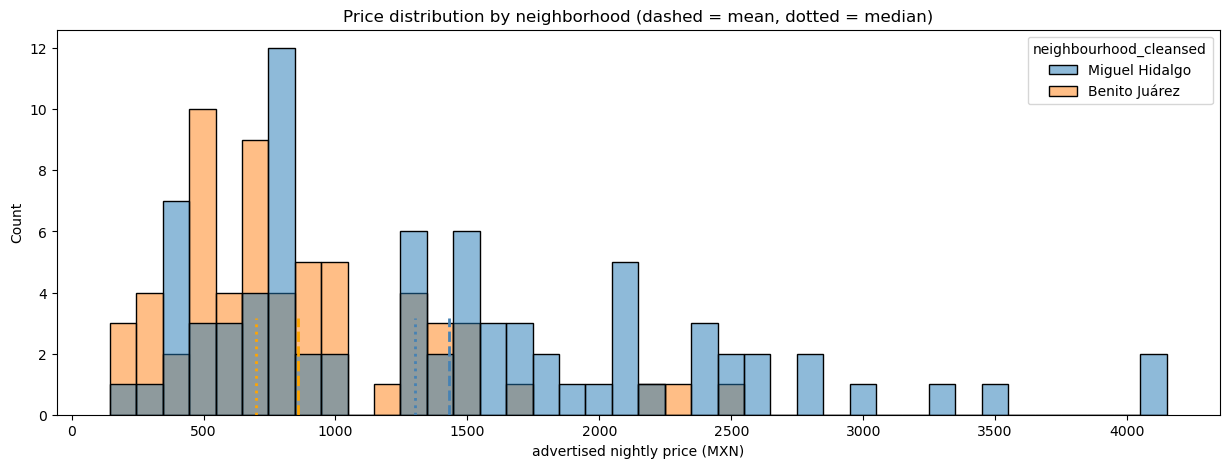

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
subset = price_df.loc[price_df["neighbourhood_cleansed"].isin(selected_neighborhoods)]

sns.histplot(data=subset, x="price", hue="neighbourhood_cleansed", bins=40, ax=ax)

for neighborhood, color in zip(selected_neighborhoods, ["steelblue", "orange"]):
    prices = price_df.loc[price_df["neighbourhood_cleansed"] == neighborhood, "price"]
    ax.axvline(prices.mean(), color=color, linestyle="dashed", linewidth=2, ymax=0.25)
    ax.axvline(prices.median(), color=color, linestyle="dotted", linewidth=2, ymax=0.25)

ax.set_xlabel(f"advertised nightly price ({CURRENCY})")
ax.set_title("Price distribution by neighborhood (dashed = mean, dotted = median)")
plt.show()

The gap between each mean and its median is the skew, and it is the reason the mean difference will carry a wide interval: a handful of expensive listings move the mean a long way in samples this size.

### Step 0. Define what difference would change the decision

Do this **before** looking at the test result, otherwise the threshold gets chosen to match whatever came out.

"Is there a difference?" and "is the difference big enough to act on?" are different questions, and only the second one has business value. A test against zero can return a decisive p-value for a difference far too small to matter — and, as we will see, an interval so wide that it is compatible with both outcomes at once.

This value might come from a business decision that answers: *at what nightly price gap would you actually change which neighborhood you buy in?*

In [21]:
# Business threshold: the smallest difference in mean nightly price that would change the investment decision
# This is a business input, not a statistic.
practical_threshold = 300.0   # MXN per night (see the estimand registry)

**Step 1.** Define null and alternative hypothesis.

Note these are statements about **population means** ($\mu$), not about the sample means we observed. We already know the sample means differ; that is not in question.

$$
H_0: \mu_1 = \mu_2
$$
$$
H_a: \mu_1 \neq \mu_2
$$

And, separately, the question the investor actually asked:

$$
H_0': \mu_1 - \mu_2 \leq \delta \qquad H_a': \mu_1 - \mu_2 > \delta \qquad (\delta = \text{practical threshold})
$$

**Step 2.** Define the significance level desired:

In [22]:
alpha = 0.01

**Step 3.** Choose the appropriate test.

We use **Welch's t-test**. Two things are worth being precise about, because both are commonly misstated:

- Welch does not *assume unequal variances*; it simply does not *require* equal ones. It keeps the two variances separate in the standard error, $\sqrt{s_1^2/n_1 + s_2^2/n_2}$, and spends the difference on fractional degrees of freedom (Welch–Satterthwaite). Using it by default costs almost no power when variances happen to be equal, and protects the error rate when they are not.
- The normality assumption is **not** about `price`. Advertised prices are strongly right-skewed and nobody expects otherwise. What needs to be approximately normal is the *sampling distribution of the difference in means*. With group sizes in the tens and a heavy right tail, the CLT is an approximation of unknown quality here — so we verify it below instead of running a normality pre-test on the raw variable.

(Why not a Shapiro–Wilk pre-test? It has no power to detect relevant departures at small $n$, rejects on trivial ones at large $n$, and conditioning the main test on its outcome distorts the error rate of the procedure as a whole.)

**Step 4.** Calculate the estimate, its interval, and the test statistic.

Reporting order is deliberate: the estimate and its interval first, the p-value last. The p-value is a summary of the interval's position relative to one particular value, not the result itself.

In [23]:
a = price_df.loc[price_df["neighbourhood_cleansed"] == selected_neighborhoods[0], "price"]
b = price_df.loc[price_df["neighbourhood_cleansed"] == selected_neighborhoods[1], "price"]

print(f"{selected_neighborhoods[0]}: n = {len(a)}, mean = {a.mean():.1f}, sd = {a.std():.1f}")
print(f"{selected_neighborhoods[1]}: n = {len(b)}, mean = {b.mean():.1f}, sd = {b.std():.1f}")

Miguel Hidalgo: n = 79, mean = 1429.2, sd = 900.7
Benito Juárez: n = 61, mean = 856.3, sd = 501.3


In [24]:
report_estimand("price", f"{selected_neighborhoods[0]} vs {selected_neighborhoods[1]}")

result = ttest_ind(a, b, equal_var=False)

ci = result.confidence_interval(confidence_level=1 - alpha)

diff = a.mean() - b.mean()

print(f"Difference in means:    {diff:.1f} {CURRENCY}/night")
print(f"CI{100 * (1 - alpha):.0f}%:                  [{ci.low:.1f}, {ci.high:.1f}] {CURRENCY}/night   (width = {ci.high - ci.low:.1f})")
print(f"t-statistic:            {result.statistic:.4f}")
print(f"degrees of freedom:     {result.df:.1f}   (fractional -> Welch, not Student)")
print(f"p-value:                {result.pvalue:.4g}")

Estimand:     Mean advertised nightly price
Units:        MXN/night
Compared:     Miguel Hidalgo vs Benito Juárez
Population:   investable listings (entire homes + private rooms; hotel and shared rooms excluded; per-neighborhood luxury tail trimmed)
Moment:       as advertised, 27 Jun - 3 Jul 2023
------------------------------------------------------------------------------
Difference in means:    572.9 MXN/night
CI99%:                  [259.2, 886.6] MXN/night   (width = 627.4)
t-statistic:            4.7764
degrees of freedom:     126.6   (fractional -> Welch, not Student)
p-value:                4.852e-06


**Read the interval before anything else.** It runs from about **259 to 887** per night: the upper end is more than three times the lower. The p-value is tiny (≈ 5e-06), and all that tiny p-value establishes is that the interval sits clear of zero. It says nothing about the fact that the same data are compatible with a gap of 260 and with a gap of 880 — which are two very different businesses.

The honest one-line summary at this point: **we have established the sign of the difference, and only the order of magnitude of its size.**

### Step 4b. Verify the normality assumption (instead of asserting it)

A bootstrap interval makes no normality assumption about the sampling distribution: it resamples the observed data directly. If it broadly agrees with Welch's interval, the t approximation is adequate for practical purposes. If it is shifted or noticeably wider, the CLT has not kicked in at this sample size and the t interval is overconfident.

This is generate-then-verify applied to a statistical assumption rather than to code.

In [25]:
def mean_diff(x, y, axis=-1):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)


boot = bootstrap(
    (a.values, b.values),
    mean_diff,
    vectorized=True,
    paired=False,
    n_resamples=10000,
    confidence_level=1 - alpha,
    method="BCa",
    random_state=RANDOM_STATE,
)

print(f"Welch CI{100 * (1 - alpha):.0f}%:   [{ci.low:.1f}, {ci.high:.1f}]")
print(f"Boot CI{100 * (1 - alpha):.0f}%:    [{boot.confidence_interval.low:.1f}, {boot.confidence_interval.high:.1f}]")

Welch CI99%:   [259.2, 886.6]
Boot CI99%:    [266.7, 896.8]


The two intervals agree to within about ten units at each end, on a width of roughly 630 — under 2%. At $n = 79$ and $61$ with this much right skew, that agreement was not guaranteed, and the point is that we *checked* rather than assumed. The t approximation is adequate here, so normality is settled and we can stop worrying about it.

### Step 4c. Verify the independence assumption

Both intervals above treat every listing as an independent observation. If some hosts contribute several listings, that is false, and both are too narrow.

The **cluster bootstrap** resamples *hosts* rather than listings, keeping each host's listings together, so a host who prices three flats with the same rule of thumb counts as one draw rather than three. Comparing its width against a listing-level bootstrap of the same design measures what the independence assumption costs.

Two things have to be right, or the comparison is meaningless:

- **Compare like with like.** The listing-level bootstrap below uses the same percentile method and the same number of resamples as the host-level one. Comparing a BCa interval against a percentile interval would confound *what* we are asking with *how* we computed it.
- **Use enough resamples.** At 5,000 resamples the Monte Carlo noise on an interval width is a few units — the same order as the effect we are trying to measure. We use 20,000 so that the comparison is not simply reading its own noise.

In [26]:
def bootstrap_diff(units_a, units_b, n_boot=20_000, seed=RANDOM_STATE):
    # Resample the *units* handed in, keeping each unit's prices together.
    # One array per listing -> the usual bootstrap; one array per host -> clustered.
    rng_local = np.random.default_rng(seed)
    stats_out = np.empty(n_boot)
    for i in range(n_boot):
        idx_a = rng_local.integers(0, len(units_a), len(units_a))
        idx_b = rng_local.integers(0, len(units_b), len(units_b))
        sample_a = np.concatenate([units_a[j] for j in idx_a])
        sample_b = np.concatenate([units_b[j] for j in idx_b])
        stats_out[i] = sample_a.mean() - sample_b.mean()
    return stats_out


def listing_units(g):
    return [np.array([p]) for p in g["price"].values]


def host_units(g):
    return [h["price"].values for _, h in g.groupby("host_id")]


group_a = price_df.loc[price_df["neighbourhood_cleansed"] == selected_neighborhoods[0]]
group_b = price_df.loc[price_df["neighbourhood_cleansed"] == selected_neighborhoods[1]]

# How much clustering is there to find in the first place?
for name, g in [(selected_neighborhoods[0], group_a), (selected_neighborhoods[1], group_b)]:
    hc = g.groupby("host_id").size()
    print(f"{name} n = {len(g)}, distinct hosts = {hc.size}, largest host = {hc.max()}, listings from multi-listing hosts = {hc[hc > 1].sum()} ({100 * hc[hc > 1].sum() / len(g):.1f}%)")

Miguel Hidalgo n = 79, distinct hosts = 75, largest host = 3, listings from multi-listing hosts = 7 (8.9%)
Benito Juárez n = 61, distinct hosts = 60, largest host = 2, listings from multi-listing hosts = 2 (3.3%)


In [27]:
naive_stats = bootstrap_diff(listing_units(group_a), listing_units(group_b))
clust_stats = bootstrap_diff(host_units(group_a), host_units(group_b))

lo_n, hi_n = np.percentile(naive_stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])
lo_c, hi_c = np.percentile(clust_stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])

print(f"{'':<24}{'CI low':>10}{'CI high':>10}{'width':>9}{'SE':>9}")
print(f"{'Welch (t, listings)':<24}{ci.low:>10.1f}{ci.high:>10.1f}{ci.high - ci.low:>9.1f}{(ci.high - ci.low) / (2 * stats.t.ppf(1 - alpha / 2, result.df)):>9.1f}")
print(f"{'Bootstrap (listings)':<24}{lo_n:>10.1f}{hi_n:>10.1f}{hi_n - lo_n:>9.1f}{naive_stats.std():>9.1f}")
print(f"{'Bootstrap (hosts)':<24}{lo_c:>10.1f}{hi_c:>10.1f}{hi_c - lo_c:>9.1f}{clust_stats.std():>9.1f}")

# Design effect: how much clustering inflates the variance of the estimate
design_effect = (clust_stats.std() / naive_stats.std()) ** 2
n_total = len(group_a) + len(group_b)
print(f"\nDesign effect (variance inflation from clustering): {design_effect:.3f}")
print(f"Effective sample size: {n_total} / {design_effect:.3f} = {n_total / design_effect:.0f} (actual n = {n_total})")

                            CI low   CI high    width       SE
Welch (t, listings)          259.2     886.6    627.4    120.0
Bootstrap (listings)         275.9     887.5    611.5    119.0
Bootstrap (hosts)            267.5     892.6    625.0    121.1

Design effect (variance inflation from clustering): 1.035
Effective sample size: 140 / 1.035 = 135 (actual n = 140)


**Read what actually came out.** The clustered interval is wider than the listing-level one, but only by about 2%: the design effect is close to 1.0 and the effective sample size is barely below the actual one. This means that, in *this* sample, host clustering costs almost nothing.

One detail in the table, so it does not distract: the listing-level *bootstrap* interval is a little narrower than the *Welch* one. That is a property of the percentile method at this sample size, not a statement about clustering — which is exactly why the clustering question is settled by comparing the two bootstrap rows to each other rather than either of them to the t interval.

The diagnostics above say why clustering is so mild here. Only about 9% of Miguel Hidalgo listings and 3% of Benito Juárez listings come from hosts with more than one listing in the sample, and the largest host contributes three. There is very little clustering here for the bootstrap to find.

Two lessons, and the second is the one that generalizes:

1. **Our own sampling made the assumption look harmless.** Drawing 2% of the market breaks up most multi-listing hosts. The full dataset contains professional operators with dozens of listings; at full size the design effect would be materially above 1 and these intervals would be visibly too narrow. A diagnostic can be clean because of how you sampled, not because the problem is absent.
2. **A check that comes back clean is still worth running.** We now *know* the independence assumption is not driving the Q1 result. Had we asserted it, we would hold the same conclusion with no right to it — and had the design effect come back near 2.0, both the interval and the p-value would have been wrong in a way that no amount of extra data would fix.

### Step 4d. Effect size

Hedges' *g* rescales the difference into standard deviations. Its real job is **comparability** — pooling results measured on different scales, as a meta-analysis does. It adds little here, where the units are already money the client understands, so treat it as secondary to the raw difference.

Two rules we follow:

- **Always report it with an interval.** *g* inherits every bit of uncertainty that the raw difference carries; printing a bare point estimate hides that behind a tidier-looking number.
- **No verbal labels.** Snapping *g* to "small / moderate / large" converts an uncertain estimate into a category and manufactures resolution the data does not support. Cohen's 0.2 / 0.5 / 0.8 are conventions from psychology research, not decision criteria — and the interval below spans two of them, which is exactly the situation in which a label misleads.

One caveat worth naming aloud: *g* uses a **pooled** standard deviation, which sits awkwardly with having chosen Welch precisely because the variances differ. With similar variances the distinction is cosmetic; with very different ones, consider Glass's delta instead.

In [28]:
def hedges_g(x, y):
    n1, n2 = len(x), len(y)
    s1, s2 = np.std(x, ddof=1), np.std(y, ddof=1)
    sp = np.sqrt(((n1 - 1) * s1 ** 2 + (n2 - 1) * s2 ** 2) / (n1 + n2 - 2))
    d = (np.mean(x) - np.mean(y)) / sp
    df_pooled = n1 + n2 - 2
    return d * (1 - 3 / (4 * df_pooled - 1))          # bias-corrected (Hedges' g)


g_boot = bootstrap(
    (a.values, b.values),
    lambda x, y: hedges_g(x, y),
    vectorized=False,
    paired=False,
    n_resamples=5_000,
    confidence_level=1 - alpha,
    method="percentile",
    random_state=RANDOM_STATE,
)

print(f"Hedges' g: {hedges_g(a.values, b.values):.3f}  CI{100 * (1 - alpha):.0f}% [{g_boot.confidence_interval.low:.3f}, {g_boot.confidence_interval.high:.3f}]")
print("Cohen's conventional reference points (psychology research, not business criteria): 0.2 / 0.5 / 0.8")

Hedges' g: 0.756  CI99% [0.385, 1.164]
Cohen's conventional reference points (psychology research, not business criteria): 0.2 / 0.5 / 0.8


**Step 5.** Interpret and decide.

Two decisions, not one. The first is statistical, the second is the one the client is paying for.

In [29]:
# Decision 1: is the difference distinguishable from zero?
if result.pvalue <= alpha:
    print(f"REJECT H0: the difference in listing price between {selected_neighborhoods[0]} and {selected_neighborhoods[1]} is statistically distinguishable from zero.")
else:
    print(f"FAIL TO REJECT H0: the difference between {selected_neighborhoods[0]} and {selected_neighborhoods[1]} is not distinguishable from zero at alpha = {alpha}.")

REJECT H0: the difference in listing price between Miguel Hidalgo and Benito Juárez is statistically distinguishable from zero.


In [30]:
def welch_against(x, y, delta0=0.0, alternative="two-sided"):
    # Welch's t-test against an arbitrary threshold, not just zero.
    n1, n2 = len(x), len(y)
    v1, v2 = np.var(x, ddof=1) / n1, np.var(y, ddof=1) / n2
    se = np.sqrt(v1 + v2)
    df = (v1 + v2) ** 2 / (v1 ** 2 / (n1 - 1) + v2 ** 2 / (n2 - 1))
    t = (np.mean(x) - np.mean(y) - delta0) / se

    if alternative == "two-sided":
        p = 2 * stats.t.sf(abs(t), df)
    elif alternative == "greater":
        p = stats.t.sf(t, df)
    else:
        p = stats.t.cdf(t, df)
    return t, df, p


# Decision 2: is the difference past the threshold that would change the decision?
t_thr, df_thr, p_thr = welch_against(a.values, b.values, delta0=practical_threshold, alternative="greater")

print(f"H0': difference <= {practical_threshold:.0f}")
print(f"t = {t_thr:.3f}, df = {df_thr:.1f}, p = {p_thr:.4g}")
print()
if p_thr <= alpha:
    print(f"The data support a difference LARGER than {practical_threshold:.0f} per night.")
else:
    print(f"The data do NOT establish a difference larger than {practical_threshold:.0f} per night, even if the difference is distinguishable from zero. Same data, different question.")

H0': difference <= 300
t = 2.275, df = 126.6, p = 0.01228

The data do NOT establish a difference larger than 300 per night, even if the difference is distinguishable from zero. Same data, different question.


**This is a knife-edge, and saying so is part of the answer.** A p-value of 0.012 against $\alpha = 0.01$ does not mean "the gap is smaller than 300". It means this sample cannot resolve the question either way at the confidence level we committed to. The 99% interval makes the same point more legibly: it runs from 259 to 887, and the threshold of 300 sits just inside its lower end.

Notice that nothing about the data changed between Decision 1 and Decision 2 — only the question did. The same sample gives an emphatic *yes* to "is there a difference?" (p ≈ 5e-06) and a shrug to "is it big enough to act on?" (p ≈ 0.012). The second is the question the client actually asked, and it is the one this sample is underpowered for.

### Sensitivity check: does the outlier trim drive the conclusion?

If removing the top tail changes the answer, then the answer is a statement about our trimming rule rather than about the neighborhoods, and the rule has to be justified on its own terms.

In [31]:
a_raw = price_untrimmed_df.loc[price_untrimmed_df["neighbourhood_cleansed"] == selected_neighborhoods[0], "price"]
b_raw = price_untrimmed_df.loc[price_untrimmed_df["neighbourhood_cleansed"] == selected_neighborhoods[1], "price"]

report_estimand("price_untrimmed", f"{selected_neighborhoods[0]} vs {selected_neighborhoods[1]}")

res_raw = ttest_ind(a_raw, b_raw, equal_var=False)
ci_raw = res_raw.confidence_interval(confidence_level=1 - alpha)

print(f"{'':<12}{'n1':>5}{'n2':>5}{'diff':>10}{'CI low':>11}{'CI high':>11}{'p':>12}")
print(f"{'trimmed':<12}{len(a):>5}{len(b):>5}{diff:>10.1f}{ci.low:>11.1f}{ci.high:>11.1f}{result.pvalue:>12.4g}")
print(f"{'untrimmed':<12}{len(a_raw):>5}{len(b_raw):>5}{a_raw.mean() - b_raw.mean():>10.1f}{ci_raw.low:>11.1f}{ci_raw.high:>11.1f}{res_raw.pvalue:>12.4g}")

Estimand:     Mean advertised nightly price
Units:        MXN/night
Compared:     Miguel Hidalgo vs Benito Juárez
Population:   investable listings, luxury tail RETAINED
Moment:       as advertised, 27 Jun - 3 Jul 2023
------------------------------------------------------------------------------
               n1   n2      diff     CI low    CI high           p
trimmed        79   61     572.9      259.2      886.6   4.852e-06
untrimmed      81   62     855.1       54.7     1655.4    0.006043


**The trim is doing real work, and this is the most consequential table in Q1.** Removing three listings — two in Miguel Hidalgo, one in Benito Juárez — moves the estimated gap from **855 to 573** and shrinks the 99% interval from roughly 1,600 wide to roughly 630.

Read the untrimmed row carefully: its interval runs from about **55 to 1,655**. A lower bound of 55 is commercially indistinguishable from zero, so without the trim we could not clear even a trivial threshold, let alone 300.

The Q1 conclusion is therefore **conditional on a modeling choice**, not a property of the neighborhoods alone. That is a legitimate position — a mid-market investor genuinely is not competing for 9,000-a-night properties — but it has to be declared in the deliverable, because an investor who *is* open to the luxury segment faces a different and far more uncertain picture.

### Part A answer: advertised nightly price

**Yes, and decisively — on this rung.** Advertised nightly prices in Miguel Hidalgo are higher than in Benito Juárez: the estimated gap is **573 per night (99% CI: 259 to 887)**, p ≈ 5e-06. It does **not** clear the 300-per-night threshold fixed in advance (p = 0.012 against $\alpha = 0.01$), and the interval remains compatible with everything from "barely worth noticing" to "three times the threshold".

What the checks bought us:

| Check | Result | What it licenses |
|---|---|---|
| Sampling distribution / normality (Step 4b) | bootstrap and t intervals agree to within 2% | the t interval can be reported as-is |
| Independence of listings (Step 4c) | design effect ≈ 1.0 | host clustering is not distorting this result *in this subsample* |
| Sensitivity to the outlier trim | gap moves 855 → 573; untrimmed CI reaches down to 55 | the conclusion depends on excluding the luxury tail, and that must be stated |

One further limit applies to all of the above: **selection for significance inflates magnitude.** Where power is limited, a result clears the significance filter only if noise ran in its favour, so the observed difference is on average larger than the true one — a reason to trust the lower end of the interval more than the point estimate.

**Do not stop here.** Everything above concerns what hosts *ask*. Whether Miguel Hidalgo is the better *investment* is a different question, and it has a different answer.

### Part B. The estimand the client actually asked about: revenue

A more expensive listing is a better investment only if it is booked comparably often. Price and occupancy are separate quantities and nothing forces them to move together — a premium neighborhood can be premium precisely *because* it is exclusive, and exclusive can mean empty.

So we run **the same Welch machinery** across a ladder of estimands: price, booked nights, and revenue under both proxies. Nothing about the statistical method changes. Only the question does.

In [32]:
def welch_row(frame, key, by="neighbourhood_cleansed", groups=selected_neighborhoods):
    # The estimand key -- not a column name -- is the argument. An unregistered
    # key raises before any arithmetic happens.
    e = estimand(key)
    x = frame.loc[frame[by] == groups[0], e["column"]].dropna().values
    y = frame.loc[frame[by] == groups[1], e["column"]].dropna().values
    res_ = ttest_ind(x, y, equal_var=False)
    ci_ = res_.confidence_interval(confidence_level=1 - alpha)
    return {"estimand": e["label"], "units": e["units"],
            groups[0]: x.mean(), groups[1]: y.mean(),
            "difference": x.mean() - y.mean(),
            "ci_low": ci_.low, "ci_high": ci_.high, "p_value": res_.pvalue}


ladder = pd.DataFrame([welch_row(price_df, k) for k in
                       ["price", "booked_nights_reviews", "revenue_reviews",
                        "booked_nights_avail", "revenue_avail"]]).set_index("estimand")

ladder["clears_alpha"] = np.where(ladder["p_value"] <= alpha, "yes", "NO")
ladder["ci_covers_0"] = np.where((ladder["ci_low"] <= 0) & (ladder["ci_high"] >= 0), "yes", "no")

# Round the money columns, but never the p-value: rounding it to 1 decimal
# would print 0.0 for both 5e-06 and 0.017, which are opposite conclusions.
display_ladder = ladder.copy()
money = [*selected_neighborhoods, "difference", "ci_low", "ci_high"]
display_ladder[money] = display_ladder[money].round(1)
display_ladder["p_value"] = ladder["p_value"].map(lambda v: f"{v:.4g}")
display_ladder

,units,Miguel Hidalgo,Benito Juárez,difference,ci_low,ci_high,p_value,clears_alpha,ci_covers_0
estimand,,,,,,,,,
Nightly price,MXN/night,1429.2,856.3,572.9,259.2,886.6,4.852e-06,yes,no
Booked nights/yr (review proxy),nights/year,35.5,29.5,6.0,-12.3,24.3,0.3945,NO,yes
Annual revenue (review proxy),MXN/year,56747.5,26090.1,30657.4,-2391.8,63706.7,0.01665,NO,yes
Booked nights/yr (availability proxy),nights/year,129.2,115.4,13.8,-44.7,72.3,0.5388,NO,yes
Annual revenue (availability proxy),MXN/year,169958.8,103644.4,66314.4,-20970.7,153599.5,0.04919,NO,yes


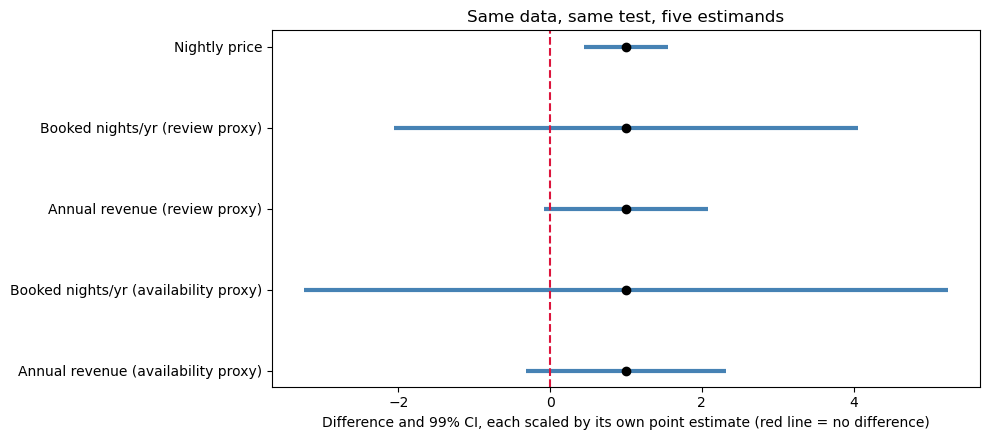

In [33]:
# Each estimand is on its own scale, so rescale every row by its own point estimate:
# the dot lands at 1.0 by construction and the interval shows its precision.
fig, ax = plt.subplots(figsize=(10, 4.5))
rows = ladder.iloc[::-1]
scale = rows["difference"].abs()
y = np.arange(len(rows))

ax.hlines(y, rows["ci_low"] / scale, rows["ci_high"] / scale, color="steelblue", linewidth=3)
ax.plot(rows["difference"] / scale, y, "o", color="black", zorder=3)
ax.axvline(0, color="crimson", linestyle="dashed", linewidth=1.5)

ax.set_yticks(y)
ax.set_yticklabels(rows.index)
ax.set_xlabel("Difference and 99% CI, each scaled by its own point estimate "
              "(red line = no difference)")
ax.set_title("Same data, same test, five estimands")
plt.tight_layout()
plt.show()

**Read the `clears_alpha` column, then read the intervals.**

- **Price** separates the two neighborhoods decisively (p ≈ 5e-06).
- **Booked nights** does not separate them at all, under *either* proxy — about 6 nights a year on the review proxy (p ≈ 0.39) and 14 on the availability proxy (p ≈ 0.54), both with intervals comfortably spanning zero. Whatever Miguel Hidalgo's premium buys, it does not buy more bookings.
- **Revenue fails to clear $\alpha = 0.01$ under both proxies** (p ≈ 0.017 and ≈ 0.049), and both intervals include zero.

**This reverses Part A's conclusion at the level that matters.** The neighborhood that is decisively more expensive is *not* detectably more lucrative: the price advantage is real, but occupancy is noisy enough to swallow it whole. The honest statement to a client is that this sample cannot establish a revenue difference between these two neighborhoods.

Note what did **not** happen. No assumption was violated, no test was misapplied, nothing was computed incorrectly. Part A was *right* — it simply answered a question adjacent to the one that was asked. This is the most common way a competent analysis misleads, and no amount of statistical rigor inside Part A would have caught it.

#### Where does the revenue gap come from?

Revenue is price × nights, so a revenue difference has exactly two possible sources: charging more, or being booked more. Splitting it is one line of arithmetic and it says something the p-values do not — **it holds whatever the sample size**, which the significance verdict above does not.

In [34]:
def relative_gap(frame, column, groups=selected_neighborhoods):
    x = frame.loc[frame["neighbourhood_cleansed"] == groups[0], column].mean()
    y = frame.loc[frame["neighbourhood_cleansed"] == groups[1], column].mean()
    return x / y - 1


gap_price = relative_gap(price_df, "price")
gap_nights = relative_gap(price_df, "booked_nights_reviews")
gap_revenue = relative_gap(price_df, "revenue_reviews")

print(f"Miguel Hidalgo vs Benito Juárez, in relative terms:")
print(f"  nightly price    {gap_price:>+8.1%}")
print(f"  booked nights    {gap_nights:>+8.1%}")
print(f"  annual revenue   {gap_revenue:>+8.1%}")
print(f"\n  price alone would predict   {(1 + gap_price) - 1:>+8.1%}")
print(f"  price x nights predicts     {(1 + gap_price) * (1 + gap_nights) - 1:>+8.1%}")
print(f"  observed revenue gap        {gap_revenue:>+8.1%}")
print("\n(The last two differ because the mean of a product is not the product of\n means -- the gap between them is the price/occupancy covariance.)")

Miguel Hidalgo vs Benito Juárez, in relative terms:
  nightly price      +66.9%
  booked nights      +20.3%
  annual revenue    +117.5%

  price alone would predict     +66.9%
  price x nights predicts      +100.8%
  observed revenue gap         +117.5%

(The last two differ because the mean of a product is not the product of
 means -- the gap between them is the price/occupancy covariance.)


**The premium is a price premium, not a demand premium.** Miguel Hidalgo charges far more per night and is booked somewhat more often, but the price term is more than three times the size of the occupancy term. Most of the revenue gap is the price column doing the work.

This is the form of the finding worth taking to a client, for a reason that matters more than it first appears: **it does not depend on the sample size.** Run the same decomposition on the full market (Part E) and the shape is unchanged — price is the dominant term, occupancy a minor one. The significance verdict above, by contrast, flips as soon as you add data.

Any conclusion that would reverse with more data is a statement about your sample. A conclusion that holds at every sample size is a statement about the market. Prefer the second kind.

### Part C. Is it the neighborhood, or the properties standing in it?

Part A compared neighborhoods as they are, mixing location with everything correlated with location. If Miguel Hidalgo listings are simply larger, part of the "neighborhood premium" is really a capacity premium, and an investor comparing two similar apartments faces a smaller gap than the headline suggests.

**Unadjusted and adjusted comparisons answer different questions, and neither is wrong.** Unadjusted: *what does a typical listing cost in each neighborhood?* — the right question for sizing a market. Adjusted: *what does the same property cost in each neighborhood?* — the right question for an investor choosing where to buy.

In [35]:
report_estimand("price_adjusted",
                f"{selected_neighborhoods[0]} vs {selected_neighborhoods[1]}")

model_df = price_df.loc[
    price_df["neighbourhood_cleansed"].isin(selected_neighborhoods)].copy()
model_df["is_first"] = (
    model_df["neighbourhood_cleansed"] == selected_neighborhoods[0]).astype(int)

print(model_df.groupby("neighbourhood_cleansed")[["accommodates", "bedrooms"]]
      .mean().round(2).to_string(), "\n")

unadjusted = smf.ols("price ~ is_first", data=model_df).fit()
adjusted = smf.ols("price ~ is_first + accommodates + C(room_type)", data=model_df).fit()

for name, model in [("unadjusted", unadjusted), ("adjusted", adjusted)]:
    lo_, hi_ = model.conf_int(alpha).loc["is_first"]
    print(f"{name:<11} neighborhood effect = {model.params['is_first']:>7.1f}   "
          f"CI{100 * (1 - alpha):.0f}% [{lo_:7.1f}, {hi_:7.1f}]   "
          f"p = {model.pvalues['is_first']:.3g}")

print(f"\nEach additional guest of capacity: {adjusted.params['accommodates']:.0f} per night")
print(f"Adjusted R-squared: {adjusted.rsquared:.3f}")

Estimand:     Mean advertised nightly price, holding capacity and room type fixed
Units:        MXN/night
Compared:     Miguel Hidalgo vs Benito Juárez
Population:   investable listings (entire homes + private rooms; hotel and shared rooms excluded; per-neighborhood luxury tail trimmed)
Moment:       as advertised, 27 Jun - 3 Jul 2023
------------------------------------------------------------------------------
                        accommodates  bedrooms
neighbourhood_cleansed                        
Benito Juárez                   3.03      1.52
Miguel Hidalgo                  3.58      1.69 

unadjusted  neighborhood effect =   572.9   CI99% [  237.5,   908.4]   p = 1.68e-05
adjusted    neighborhood effect =   464.0   CI99% [  199.0,   729.1]   p = 1.07e-05

Each additional guest of capacity: 168 per night
Adjusted R-squared: 0.471


Miguel Hidalgo listings do sleep more people on average, and capacity is worth roughly **168 per guest per night**. Holding capacity and room type fixed, the neighborhood premium falls from **573 to about 464** — still comfortably clear of zero.

Composition therefore explains about a fifth of the headline gap, and a genuine location premium survives. Quoting the unadjusted 573 to an investor comparing two similar apartments would overstate their decision by roughly 20%.

### Part D. "Most lucrative **neighborhoods**" is a ranking question

Parts A to C compare a single pair, fixed in advance. The brief asks us to *identify the most lucrative neighborhoods* — an argmax over all of them, which no two-sample test can deliver.

The instinct is to run every pairwise test. Resist it: eight neighborhoods give 28 pairs, and a procedure that tests all of them at $\alpha = 0.01$ produces a false "winner" far more often than 1% of the time. The honest alternative is to **estimate every neighborhood's mean with an interval, then ask how much of the ordering the data actually supports.**

In [36]:
MIN_GROUP = 10


def bootstrap_mean_ci(values, n_boot=5_000, conf=0.95, seed=RANDOM_STATE):
    rng_local = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    means = np.array([rng_local.choice(values, values.size, replace=True).mean()
                      for _ in range(n_boot)])
    lo_, hi_ = np.percentile(means, [100 * (1 - conf) / 2, 100 * (1 + conf) / 2])
    return values.mean(), lo_, hi_


sizes = price_df.groupby("neighbourhood_cleansed").size()
eligible = sizes[sizes >= MIN_GROUP].index

rows = []
for nb in eligible:
    g = price_df.loc[price_df["neighbourhood_cleansed"] == nb]
    mean_rev, lo_rev, hi_rev = bootstrap_mean_ci(g["revenue_reviews"].values)
    rows.append({"neighborhood": nb, "n": len(g),
                 "mean_price": g["price"].mean(),
                 "mean_revenue": mean_rev, "ci_low": lo_rev, "ci_high": hi_rev})

ranking = (pd.DataFrame(rows)
           .sort_values("mean_revenue", ascending=False)
           .reset_index(drop=True))
ranking.round(0)

,neighborhood,n,mean_price,mean_revenue,ci_low,ci_high
0,Cuauhtémoc,226,1192.0,72546.0,58667.0,87045.0
1,Miguel Hidalgo,79,1429.0,56748.0,36316.0,80466.0
2,Benito Juárez,61,856.0,26090.0,16440.0,37706.0
3,Álvaro Obregón,18,944.0,25737.0,10234.0,46030.0
4,Tlalpan,18,1277.0,24177.0,7263.0,44373.0
5,Coyoacán,26,900.0,23890.0,12748.0,36353.0
6,Venustiano Carranza,16,600.0,19956.0,7822.0,34625.0
7,Gustavo A. Madero,10,408.0,7177.0,1346.0,14842.0


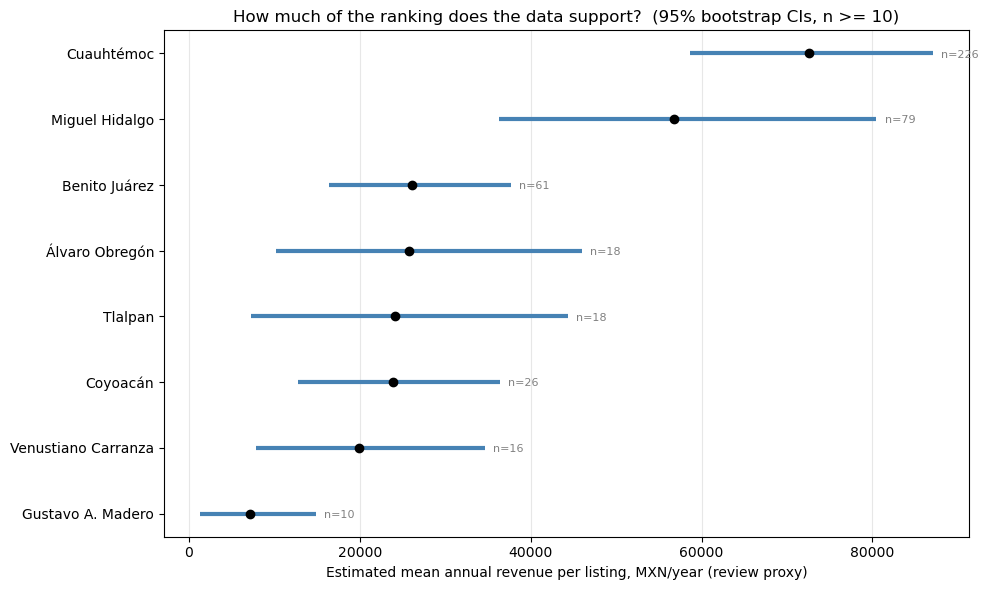

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
order = ranking.iloc[::-1].reset_index(drop=True)
y = np.arange(len(order))

ax.hlines(y, order["ci_low"], order["ci_high"], color="steelblue", linewidth=3)
ax.plot(order["mean_revenue"], y, "o", color="black", zorder=3)
for i, row in order.iterrows():
    ax.annotate(f"n={row['n']:.0f}", (row["ci_high"], i), xytext=(6, -3),
                textcoords="offset points", fontsize=8, color="gray")

ax.set_yticks(y)
ax.set_yticklabels(order["neighborhood"])
ax.set_xlabel(f"Estimated mean annual revenue per listing, {CURRENCY}/year (review proxy)")
ax.set_title(f"How much of the ranking does the data support?  "
             f"(95% bootstrap CIs, n >= {MIN_GROUP})")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# A conservative screen, NOT a formal test: non-overlapping intervals imply a
# difference, but overlapping ones do not imply its absence.
pairs = separated = 0
for i in range(len(ranking)):
    for j in range(i + 1, len(ranking)):
        pairs += 1
        if ranking.loc[i, "ci_low"] > ranking.loc[j, "ci_high"]:
            separated += 1

print(f"Pairs of neighborhoods:               {pairs}")
print(f"Pairs with non-overlapping intervals: {separated} ({100 * separated / pairs:.0f}%)")
print(f"\nSpearman correlation, price rank vs revenue rank: "
      f"{ranking['mean_price'].rank().corr(ranking['mean_revenue'].rank(), method='spearman'):.3f}")

Pairs of neighborhoods:               28
Pairs with non-overlapping intervals: 9 (32%)

Spearman correlation, price rank vs revenue rank: 0.714


**The ranking is mostly not a ranking.** Only about a third of the 28 pairs have non-overlapping intervals; for the rest, this data cannot say which neighborhood earns more. The defensible output is not an ordered list but a coarse grouping — Cuauhtémoc clearly above the bottom half, Miguel Hidalgo somewhere in the upper region, and the remainder mutually indistinguishable at this sample size.

Two things deserve saying out loud.

**Cuauhtémoc leads the ranking — and it was excluded by assumption.** The pair used in Parts A–C was fixed on the business ground that Cuauhtémoc's saturation "undercuts investment potential". On this evidence it has both the highest estimated revenue and the tightest interval, because it has by far the most listings. That premise may still be correct — saturation is a claim about *future* competition, not current revenue — but it was never tested, and it removed the apparent front-runner before any analysis ran. **An unexamined business assumption can determine a conclusion just as thoroughly as a statistical error, and it is far less likely to be audited.**

**Price ranking and revenue ranking are not the same ordering.** Their Spearman correlation is about 0.7, not 1.0 — Tlalpan sits among the most expensive neighborhoods and mid-table for revenue. A shortlist built on price would differ from one built on revenue.

A caution on method: comparing intervals by eye is a **conservative screen, not a test**. Non-overlapping intervals do imply a difference, but overlapping ones do not imply its absence — two intervals can overlap while a direct test of their difference still rejects. The purpose here is to show how little of the ordering is pinned down, not to certify individual pairs.

### Part E. How much of this is the sample, and how much is the market?

Every number so far came from one 2% draw. Two separate questions follow, and they are easy to confuse:

- **How much data?** (`SAMPLE_FRAC`) — governs *precision*. More data narrows intervals.
- **Which data?** (`RANDOM_STATE`) — governs *luck*. A different draw of the same size gives different numbers.

The rest of the notebook holds both fixed, exactly as a real analysis must: you get the sample you get. But holding them fixed means the notebook cannot show what they do — and what they do is most of what a course on inference is about. So we re-run the entire pipeline across both.

In [39]:
def q1_pipeline(frac, seed=RANDOM_STATE):
    # A condensed repeat of every preparation step above, so that the one input
    # we care about -- the sample -- can be varied. Deliberately duplicated
    # rather than refactored: the steps above are the teaching version.
    df = all_listings_df.sample(frac=frac, random_state=seed).copy()
    df["price"] = df["price"].str.replace("[$,]", "", regex=True).astype(float)
    df = df.loc[df["price"].notna() & (df["price"] > 0)]

    stay = df["minimum_nights"].clip(1, MAX_STAY_NIGHTS)
    df["booked_nights_reviews"] = np.minimum(
        df["number_of_reviews_ltm"] / REVIEW_RATE * stay, 365 * MAX_OCCUPANCY)
    df["revenue_reviews"] = df["booked_nights_reviews"] * df["price"]

    df = df.loc[~df["room_type"].isin(["Hotel room", "Shared room"])]
    return df.loc[df["price"] <= df.groupby("neighbourhood_cleansed")["price"]
                  .transform(upper_fence)]


def _boot_means(sums, sizes, n_boot, rng_local):
    # Resample units and form the mean as (sum of sampled sums) / (sum of sizes).
    # One row per listing -> ordinary bootstrap; one row per host -> clustered.
    idx = rng_local.integers(0, len(sums), (n_boot, len(sums)))
    return sums[idx].sum(axis=1) / sizes[idx].sum(axis=1)


def design_effect(frame_a, frame_b, n_boot=1_000, seed=RANDOM_STATE):
    rng_local = np.random.default_rng(seed)
    spreads = []
    for by_host in (False, True):
        draws = []
        for g in (frame_a, frame_b):
            if by_host:
                agg = g.groupby("host_id")["price"].agg(["sum", "size"])
                s, n = agg["sum"].values, agg["size"].values.astype(float)
            else:
                s, n = g["price"].values, np.ones(len(g))
            draws.append(_boot_means(s, n, n_boot, rng_local))
        spreads.append((draws[0] - draws[1]).std())
    return (spreads[1] / spreads[0]) ** 2          # clustered variance / naive variance

In [40]:
rows = []
for frac in [0.02, 0.05, 0.10, 0.25, 0.50, 1.00]:
    p = q1_pipeline(frac)
    A = p.loc[p["neighbourhood_cleansed"] == selected_neighborhoods[0]]
    B = p.loc[p["neighbourhood_cleansed"] == selected_neighborhoods[1]]

    res_p = ttest_ind(A["price"], B["price"], equal_var=False)
    ci_p = res_p.confidence_interval(confidence_level=1 - alpha)
    res_r = ttest_ind(A["revenue_reviews"], B["revenue_reviews"], equal_var=False)

    hosts = pd.concat([A, B]).groupby("host_id").size()
    by_nb = p.groupby("neighbourhood_cleansed")
    ranked = (by_nb["revenue_reviews"].mean()[by_nb.size() >= MIN_GROUP]
              .sort_values(ascending=False))

    rows.append({"sample": f"{frac:.0%}", "n": len(A) + len(B),
                 "price_diff": A["price"].mean() - B["price"].mean(),
                 "ci_width": ci_p.high - ci_p.low,
                 "p_price": res_p.pvalue, "p_revenue": res_r.pvalue,
                 "multi_host_pct": 100 * hosts[hosts > 1].sum() / (len(A) + len(B)),
                 "design_effect": design_effect(A, B),
                 "top_3_by_revenue": " > ".join(ranked.index[:3])})

sweep = pd.DataFrame(rows).set_index("sample")

show = sweep.copy()
show[["price_diff", "ci_width", "multi_host_pct", "design_effect"]] = \
    show[["price_diff", "ci_width", "multi_host_pct", "design_effect"]].round(1)
show["p_price"] = sweep["p_price"].map(lambda v: f"{v:.1g}")
show["p_revenue"] = sweep["p_revenue"].map(lambda v: f"{v:.1g}")
show = show.rename(columns={"multi_host_pct": "multi_host_%"})
show

,n,price_diff,ci_width,p_price,p_revenue,multi_host_%,design_effect,top_3_by_revenue
sample,,,,,,,,
2%,140,572.9,627.4,5e-06,0.02,6.4,1.0,Cuauhtémoc > Miguel Hidalgo > Benito Juárez
5%,385,711.4,403.1,6e-18,0.0002,20.0,1.0,Miguel Hidalgo > Cuauhtémoc > Iztacalco
10%,768,602.9,267.3,9e-29,4e-08,27.6,1.4,Cuauhtémoc > Miguel Hidalgo > Iztacalco
25%,1887,552.7,174.6,6e-56,5e-13,38.8,2.1,Cuauhtémoc > Miguel Hidalgo > Iztacalco
50%,3752,583.4,123.1,6e-122,2e-28,49.3,3.7,Cuauhtémoc > Miguel Hidalgo > Venustiano Carranza
100%,7487,601.0,86.4,4e-258,3e-52,60.2,6.5,Cuauhtémoc > Miguel Hidalgo > Venustiano Carranza


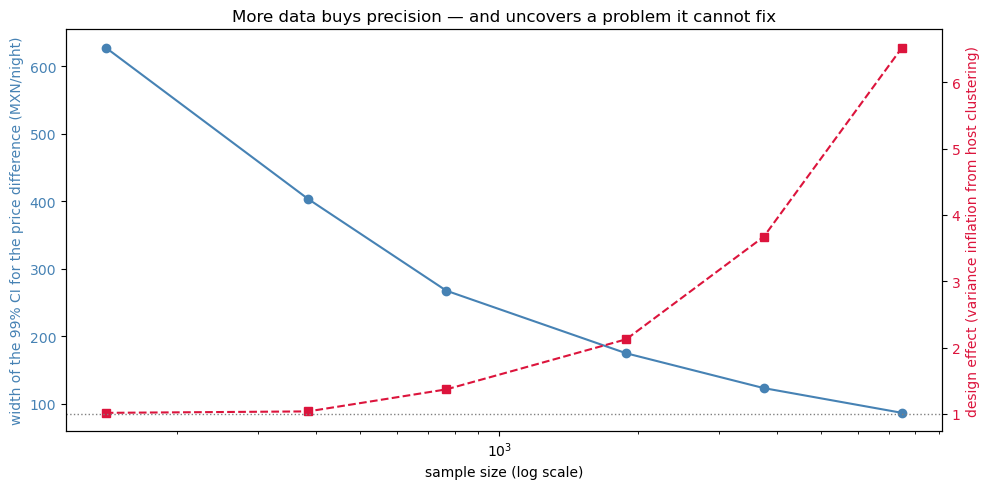

In [41]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(sweep["n"], sweep["ci_width"], "o-", color="steelblue", label="99% CI width")
ax1.set_xscale("log")
ax1.set_xlabel("sample size (log scale)")
ax1.set_ylabel(f"width of the 99% CI for the price difference ({CURRENCY}/night)",
               color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(sweep["n"], sweep["design_effect"], "s--", color="crimson",
         label="design effect")
ax2.axhline(1.0, color="gray", linestyle=":", linewidth=1)
ax2.set_ylabel("design effect (variance inflation from host clustering)",
               color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")

ax1.set_title("More data buys precision — and uncovers a problem it cannot fix")
fig.tight_layout()
plt.show()

**Two curves moving in opposite directions, and that is the whole lesson.**

**The blue curve is the good news.** The interval narrows from roughly 630 wide to under 90 — precision improves as $1/\sqrt{n}$, which is why it takes a 25× larger sample to halve the width twice. Note what does *not* move: the estimate itself sits near 570–600 at every size. More data did not change the answer; it sharpened it.

**The red curve is the bad news, and it is the more important one.** At 2% the design effect is ≈ 1.0, which is why the independence check in Step 4c came back clean and undramatic. It was clean **because of how little we sampled**: at 2% barely 6% of these listings share a host, so there was almost no clustering to find. Take the full market and 60% share a host, the design effect reaches **≈ 6.5**, and the conventional interval is roughly $\sqrt{6.5} \approx 2.5$ times too narrow.

**So a 25× larger sample does not buy 25× more information here.** Its effective sample size is a fraction of its nominal one, and an analyst who reported the naive interval at full scale would be far more confident, and far more wrong, than we are now. This is the single clearest illustration in the notebook of why assumption checks are not a formality: the assumption got *worse* precisely as the data got better, and only a check would reveal it.

Two smaller things the table shows:

- **`p_revenue` is not a property of the market.** It crosses from 0.017 at 2% to essentially zero by 5%. Same market, same estimand, same method — only the sample size changed. A p-value describes the evidence you have, not the truth you are after.
- **The ranking is not stable at 2%.** Miguel Hidalgo and Cuauhtémoc swap the top spot at 5%, and third place is held by a different neighborhood at almost every sample size: Benito Juárez at 2%, then Iztacalco — too small to even qualify for our 2% ranking — from 5% to 25%, then Venustiano Carranza, second from last in our 2% ranking, from 50% on. Part D's caution was not hedging.

In [42]:
# Same question, from the other direction: fix the sample SIZE and vary the DRAW.
seed_rows = []
for seed in range(1, 26):
    p = q1_pipeline(SAMPLE_FRAC, seed=seed)
    A = p.loc[p["neighbourhood_cleansed"] == selected_neighborhoods[0]]
    B = p.loc[p["neighbourhood_cleansed"] == selected_neighborhoods[1]]
    if min(len(A), len(B)) < 5:
        continue
    seed_rows.append({
        "seed": seed,
        "price_diff": A["price"].mean() - B["price"].mean(),
        "p_price": ttest_ind(A["price"], B["price"], equal_var=False).pvalue,
        "p_revenue": ttest_ind(A["revenue_reviews"], B["revenue_reviews"],
                               equal_var=False).pvalue,
    })

seeds_df = pd.DataFrame(seed_rows)

print(f"{len(seeds_df)} different 2% samples of the same market:\n")
print(f"  price difference ranged from {seeds_df['price_diff'].min():.0f} "
      f"to {seeds_df['price_diff'].max():.0f} "
      f"(our draw: {price_df.loc[price_df['neighbourhood_cleansed'] == selected_neighborhoods[0], 'price'].mean() - price_df.loc[price_df['neighbourhood_cleansed'] == selected_neighborhoods[1], 'price'].mean():.0f})")
print(f"  price   significant at alpha={alpha}: "
      f"{100 * (seeds_df['p_price'] <= alpha).mean():.0f}% of draws")
print(f"  revenue significant at alpha={alpha}: "
      f"{100 * (seeds_df['p_revenue'] <= alpha).mean():.0f}% of draws")

25 different 2% samples of the same market:

  price difference ranged from 285 to 888 (our draw: 573)
  price   significant at alpha=0.01: 96% of draws
  revenue significant at alpha=0.01: 28% of draws


**Read the last line against our own conclusion.** Part B reported that revenue did not clear $\alpha$ — and that verdict holds in only about a quarter of equally valid 2% samples. Had we drawn a different one, we might have reported the opposite.

This is not a flaw in the analysis; it is what a small sample *is*, and it is why the notebook reports intervals rather than verdicts. But it does change how the Part B result should be written down:

- ❌ *"There is no revenue difference between the neighborhoods."* — contradicted by a different draw, and by the full market.
- ✅ *"This sample cannot resolve a revenue difference, and the gap that exists is almost entirely a price gap rather than an occupancy gap."* — true of our draw, true of other draws, and true of the full market.

The first sentence reports the p-value. The second reports the estimate, its precision, and its composition. **Only the second survives contact with a different sample** — which is the practical reason the notebook insists on reporting the estimate and its interval before the p-value.

One honest caveat about this cell: we could check our luck only because we happen to hold the full market. A real analyst cannot re-draw, which is exactly why the interval — computable from a single sample — is the tool that stands in for this experiment.

### Answer to business question 1

**Which neighborhoods are most lucrative? On this sample the question cannot be answered at the precision an investor needs — and the price analysis alone would have answered it wrongly.**

| Rung | Finding | Verdict |
|---|---|---|
| Advertised price, MH vs BJ | +573/night, CI99 [259, 887], p ≈ 5e-06 | Miguel Hidalgo clearly higher |
| Same, adjusted for capacity and room type | +464/night, CI99 [199, 729] | premium survives, ~20% smaller |
| Booked nights, MH vs BJ | +6/yr, CI99 [−12, +24], p ≈ 0.39 | no detectable difference |
| Annual revenue, MH vs BJ | not significant under either proxy (p ≈ 0.017 / 0.049) | **no detectable difference** |
| Revenue ranking, 8 neighborhoods | about a third of pairs separable | Cuauhtémoc above the bottom half; the rest unresolved |
| Composition of the revenue gap | price +67%, occupancy +20% | the premium is a **price** premium, not a demand premium |
| Stability across samples (Part E) | revenue verdict holds in ~1 in 4 draws; design effect reaches 6.5 at full scale | the null is a statement about this sample, not the market |

**The recommendation.** Miguel Hidalgo commands a genuine price premium over Benito Juárez, but this sample gives no evidence that the premium converts into higher revenue, and no basis for ranking most neighborhoods against one another. A deliverable that says *"invest in Miguel Hidalgo because prices are significantly higher"* uses a statistically impeccable result to support a claim the analysis never tested.

What would actually settle it: the full dataset instead of a 2% sample — though Part E shows that would raise the design effect to ≈ 6.5, so the extra data must be analysed with host clustering handled, not merely counted — plus a calendar- or booking-level source instead of a review-based proxy, and acquisition costs, without which none of this is a return.

### The hard boundary: revenue is not return

Everything above stops at the revenue rung. The gap between that and what an investor actually maximizes is **not a statistical problem — it is missing data**, and no test, sample size or model in this notebook can close it.

Absent from this dataset entirely:

- **Acquisition cost.** The denominator of any return. A neighborhood earning 30% more, on property costing twice as much, is the worse investment — and nothing here would reveal it.
- **Operating costs.** Cleaning, laundry, utilities, maintenance, property management (commonly around 20% of revenue), platform commission, furnishing capex.
- **Carrying costs.** Property tax, building fees, insurance, financing.
- **Regulatory risk.** Short-term-rental rules in Mexico City changed during the period these listings cover, and enforcement varies by borough — a factor capable of dominating every difference measured above.

**A correct deliverable states this boundary rather than implying it away.** *"Miguel Hidalgo listings advertise roughly 40% higher nightly prices with no detectable revenue advantage, and return cannot be assessed without acquisition costs"* is a useful, honest finding. *"Miguel Hidalgo is the better investment"* is not supported by anything in this notebook.

## Business question 2

*"To select the best room type to invest in, are there room types that are more prevalent in certain neighborhoods?"*

**Read that twice, because it does not hold together.** Prevalence tells you what is *common*; the goal is what is *profitable*. Even a decisive answer about prevalence would not identify the best room type to invest in — common could mean lucrative, or it could mean crowded and cheap. The statistical test is fine; the inference from it to the business goal does not exist.

So we split it into the two questions it conflates, and answer both:

- **Q2a — market structure.** Does room-type composition differ across neighborhoods? This is what a chi-square test of independence actually answers.
- **Q2b — the decision.** Does room type predict revenue? This is what "the best room type to invest in" requires, and it is a comparison of means, not of proportions.

Q2a keeps **all** room types (rare ones collapsed into `Other`), not the investor-relevant subset from Q1. Question 1 asks about a market an investor would enter; Q2a asks how the market is composed, and dropping categories in advance would answer a narrower question than the one posed.

### Q2a. Market structure

In [43]:
neighborhood_frec_cumsum = (listings_df["neighbourhood_cleansed"]
                            .value_counts(dropna=False, normalize=True)
                            .cumsum())
neighborhood_frec_cumsum

neighbourhood_cleansed
Cuauhtémoc                0.476378
Miguel Hidalgo            0.637795
Benito Juárez             0.761811
Coyoacán                  0.820866
Álvaro Obregón            0.858268
Tlalpan                   0.893701
Venustiano Carranza       0.925197
Gustavo A. Madero         0.944882
Cuajimalpa de Morelos     0.962598
Iztacalco                 0.972441
Iztapalapa                0.980315
Xochimilco                0.988189
Azcapotzalco              0.994094
La Magdalena Contreras    0.998031
Tláhuac                   1.000000
Name: proportion, dtype: float64

In [44]:
# Pareto filter at 85%: keep neighborhoods up to AND INCLUDING the one that crosses
# the threshold. A strict `< 0.85` silently drops the crossing neighborhood.
PARETO = 0.85
mask = neighborhood_frec_cumsum.shift(fill_value=0) < PARETO
most_representative_neighborhoods = neighborhood_frec_cumsum.loc[mask].index.tolist()
most_representative_neighborhoods

['Cuauhtémoc', 'Miguel Hidalgo', 'Benito Juárez', 'Coyoacán', 'Álvaro Obregón']

In [45]:
q2_df = listings_df.loc[
    listings_df["neighbourhood_cleansed"].isin(most_representative_neighborhoods)]

contingency_table = pd.crosstab(q2_df["neighbourhood_cleansed"], q2_df["room_type_grouped"])
contingency_table

room_type_grouped,Entire home/apt,Other,Private room
neighbourhood_cleansed,,,
Benito Juárez,44,1,18
Coyoacán,12,2,16
Cuauhtémoc,168,6,68
Miguel Hidalgo,62,1,19
Álvaro Obregón,12,1,6


**Step 1.** Define null and alternative hypothesis:

$$
H_0: \text{The variables are independent}
$$
$$
H_a: \text{The variables are not independent}
$$

("Not dependent" and "independent" are the same thing here, but the second is the statement the test actually evaluates — worth being exact about in a course on inference.)

**Step 2.** Define the significance level desired:

In [46]:
alpha = 0.01

**Step 3.** Check the assumption before running the test.

The chi-square statistic relies on a large-sample approximation. The usual rule of thumb is that **every expected cell count should be at least 5** — and with a 2% subsample spread across several neighborhoods and three room types, that is a real risk rather than a formality.

If the rule fails, we do not get to note it and run the test anyway. The options are to collapse sparse categories further, or to drop the approximation and compute the null distribution directly with a **permutation test**. We take the second route below.

In [47]:
report_estimand("room_type_mix", "across the Pareto-85% neighborhoods")

chi2, pvalue, dof, expected = chi2_contingency(contingency_table, correction=False)

expected_df = pd.DataFrame(expected,
                           index=contingency_table.index,
                           columns=contingency_table.columns)

print(f"Minimum expected count: {expected.min():.2f}")
print(f"Cells with expected < 5: {(expected < 5).sum()} out of {expected.size}")
if expected.min() < 5:
    print("WARNING: the chi-square approximation is unreliable here. "
          "Collapse categories or use an exact / permutation test.")
expected_df.round(1)

Estimand:     Distribution of listings across room types
Units:        share of listings
Compared:     across the Pareto-85% neighborhoods
Population:   all room types, rare ones collapsed into 'Other', Pareto-85% neighborhoods
Moment:       27 Jun - 3 Jul 2023
------------------------------------------------------------------------------
Minimum expected count: 0.48
Cells with expected < 5: 4 out of 15


room_type_grouped,Entire home/apt,Other,Private room
neighbourhood_cleansed,,,
Benito Juárez,43.1,1.6,18.4
Coyoacán,20.5,0.8,8.7
Cuauhtémoc,165.4,6.1,70.5
Miguel Hidalgo,56.0,2.1,23.9
Álvaro Obregón,13.0,0.5,5.5


### Step 3b. Replace the approximation with a permutation test

The warning above is not decorative: 4 of the 15 expected counts fall below 5, and the smallest is about 0.5. The chi-square curve is the wrong reference distribution for a table this sparse.

A permutation test needs no such curve. Under $H_0$ the two variables are independent, so shuffling one of them relative to the other generates tables drawn from exactly the null we are testing. Recomputing the statistic across many shuffles gives the null distribution we actually need, and the p-value is the share of shuffled tables at least as extreme as the observed one.

In [48]:
def permutation_chi2(frame, col_a, col_b, n_perm=10_000, seed=RANDOM_STATE):
    observed = chi2_contingency(pd.crosstab(frame[col_a], frame[col_b]),
                                correction=False)[0]
    rng_local = np.random.default_rng(seed)
    a_vals, b_vals = frame[col_a].values, frame[col_b].values

    null = np.empty(n_perm)
    for i in range(n_perm):
        null[i] = chi2_contingency(pd.crosstab(a_vals, rng_local.permutation(b_vals)),
                                   correction=False)[0]

    # +1 top and bottom: the observed table is itself one valid arrangement,
    # which also keeps the p-value away from an impossible exact zero.
    p_perm = (np.sum(null >= observed) + 1) / (n_perm + 1)
    return observed, p_perm, null


chi2_obs, p_perm, null_dist = permutation_chi2(
    q2_df, "neighbourhood_cleansed", "room_type_grouped")

print(f"chi-square (observed):  {chi2_obs:.4f}")
print(f"p-value (asymptotic):   {pvalue:.4f}")
print(f"p-value (permutation):  {p_perm:.4f}   <- the one to report")

chi-square (observed):  14.8431
p-value (asymptotic):   0.0623
p-value (permutation):  0.0657   <- the one to report


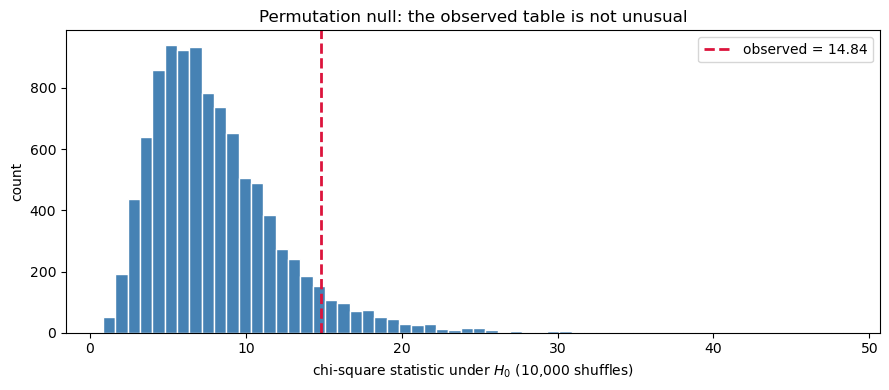

In [49]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(null_dist, bins=60, color="steelblue", edgecolor="white")
ax.axvline(chi2_obs, color="crimson", linestyle="dashed", linewidth=2,
           label=f"observed = {chi2_obs:.2f}")
ax.set_xlabel("chi-square statistic under $H_0$ (10,000 shuffles)")
ax.set_ylabel("count")
ax.set_title("Permutation null: the observed table is not unusual")
ax.legend()
plt.tight_layout()
plt.show()

The permutation p-value lands essentially on top of the asymptotic one (≈ 0.066 against ≈ 0.062). The sparse cells did not, in the end, distort the result.

That is worth pausing on, because it is the second check in this notebook to come back clean. The value of a check is not that it overturns the answer — usually it will not — but that afterwards you know rather than hope. A tutorial that only showed checks which changed the conclusion would teach students to expect drama, and to skip the check whenever they did not anticipate any.

**Step 4.** Calculate the statistic, p-value, and effect size.

In [50]:
n = contingency_table.values.sum()
r, k = contingency_table.shape

phi2 = chi2 / n
phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
r_corr = r - ((r - 1) ** 2) / (n - 1)
k_corr = k - ((k - 1) ** 2) / (n - 1)

cramers_v = np.sqrt(phi2_corr / max(1e-12, min(r_corr - 1, k_corr - 1)))  # bias-corrected

In [51]:
print(f"chi-square: {chi2:.4f}")
print(f"dof:        {dof}")
print(f"p-value:    {pvalue:.4g}")
print(f"Cramér's V: {cramers_v:.3f}")

# Cohen's 0.1 / 0.3 / 0.5 reference points are defined for dof = 1 tables.
# For larger tables they must be scaled by sqrt(min(r-1, k-1)).
df_star = min(r - 1, k - 1)
scaled = ", ".join(f"{x / np.sqrt(df_star):.3f}" for x in (0.1, 0.3, 0.5))
print(f"\nReference points for a table with min(r-1, k-1) = {df_star}: {scaled}")
print("These are conventions, not thresholds. Report V; do not convert it to a label.")

chi-square: 14.8431
dof:        8
p-value:    0.06227
Cramér's V: 0.089

Reference points for a table with min(r-1, k-1) = 2: 0.071, 0.212, 0.354
These are conventions, not thresholds. Report V; do not convert it to a label.


**Step 5.** Interpret and decide.

In [52]:
if p_perm <= alpha:
    print("REJECT H0: neighborhood and room type are not independent in this sample.")
else:
    print(f"FAIL TO REJECT H0 (permutation p = {p_perm:.4f} > alpha = {alpha}).")
    print("Room-type composition is not distinguishable across these neighborhoods.")

FAIL TO REJECT H0 (permutation p = 0.0657 > alpha = 0.01).
Room-type composition is not distinguishable across these neighborhoods.


### A note on what we are deliberately *not* doing

The natural next move is to inspect standardized residuals to find the cell that "caused" the association. **We will not read them as findings here, because there is no association to decompose.**

Hunting through 15 cells for the one that looks extreme, after an omnibus test that failed to reject, is the same error the notebook warned about when choosing which neighborhoods to compare: with enough cells, something always looks notable. The map below is printed for one legitimate purpose — an *exploratory* description of where a larger future study might look first — and for no other.

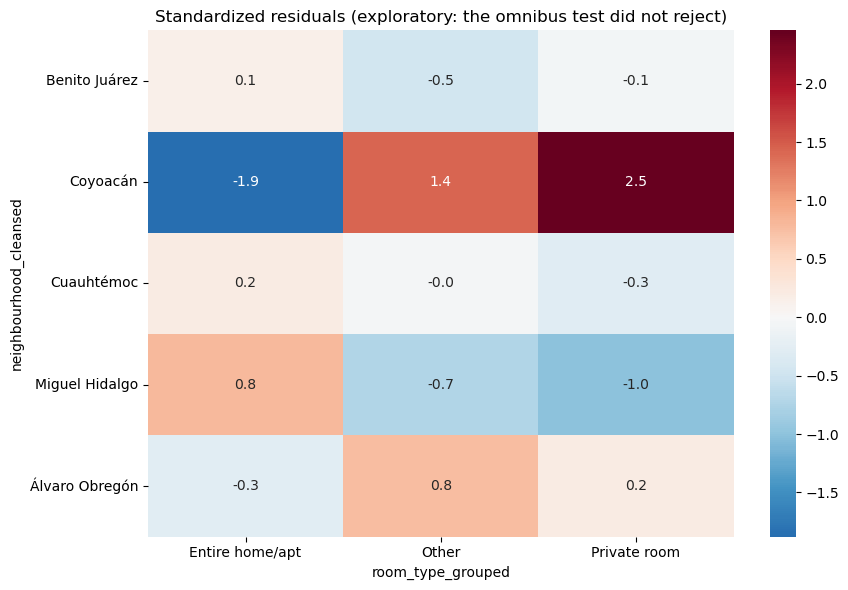

room_type_grouped,Entire home/apt,Other,Private room
neighbourhood_cleansed,,,
Benito Juárez,0.14,-0.47,-0.08
Coyoacán,-1.88,1.43,2.46
Cuauhtémoc,0.20,-0.04,-0.30
Miguel Hidalgo,0.80,-0.74,-1.00
Álvaro Obregón,-0.27,0.75,0.20


In [53]:
# Standardized (Pearson) residuals: (observed - expected) / sqrt(expected)
# Exploratory only: the omnibus test did not reject, so no cell here is a finding.
residuals = (contingency_table - expected_df) / np.sqrt(expected_df)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(residuals, annot=True, fmt=".1f", center=0, cmap="RdBu_r", ax=ax)
ax.set_title("Standardized residuals (exploratory: the omnibus test did not reject)")
plt.tight_layout()
plt.show()

residuals.round(2)

### Q2a answer: does composition differ by neighborhood?

**No — not on this evidence.** Room-type composition is statistically indistinguishable across the five neighborhoods making up 85% of the listings: permutation p ≈ 0.066 against $\alpha = 0.01$, with Cramér's V ≈ 0.09, near the bottom of its range.

The largest single residual is Coyoacán's private rooms at about +2.5 — exactly the kind of cell that would have been over-interpreted had we gone looking for it. It does not survive the omnibus test, and among 15 cells a residual that size is unremarkable under pure chance.

**"No association detected" is not "no association exists."** With 508 listings narrowed to five neighborhoods this design has limited power, and a real but modest composition difference would very likely go undetected. Even a detected association would not be causal: prevalence differences are equally consistent with zoning rules, building-stock age, tourism corridors, and platform-level enforcement of short-term-rental regulation.

### Q2b. The question the investor actually needs: does room type pay?

Q2a found nothing, and that is a real answer — but notice it would not have helped even had it found something. Choosing a room type requires **revenue by room type**, which is the same comparison of means as Part B applied to a different grouping.

We use the full listing set here rather than the Q1 subset, since the question is which room type to *operate*, not which apartment to buy.

**That makes this a different estimand from Part B, not merely a different grouping**, and the printed population below says so. Same quantity, same units, same test — a different set of listings underneath. Comparing this revenue figure directly against Part B's would be comparing two populations and calling it one finding.

In [54]:
room_summary = (listings_df.groupby("room_type_grouped")
                .agg(n=("price", "size"),
                     mean_price=("price", "mean"),
                     mean_booked=("booked_nights_reviews", "mean"),
                     mean_revenue=("revenue_reviews", "mean"),
                     median_revenue=("revenue_reviews", "median")))
room_summary.round(1)

,n,mean_price,mean_booked,mean_revenue,median_revenue
room_type_grouped,,,,,
Entire home/apt,334,1629.5,53.6,75205.1,35200.0
Other,11,2537.5,6.9,8028.7,0.0
Private room,163,802.8,25.2,13434.0,3200.0


In [55]:
ROOM_TYPES = ["Entire home/apt", "Private room"]

report_estimand("revenue_reviews", " vs ".join(ROOM_TYPES),
                population=EVERY_LISTING)   # NOT the Q1 population -- see above

q2b = pd.DataFrame([
    welch_row(listings_df, key, by="room_type_grouped", groups=ROOM_TYPES)
    for key in ["price", "booked_nights_reviews", "revenue_reviews"]
]).set_index("estimand")

q2b_show = q2b.copy()
num = [*ROOM_TYPES, "difference", "ci_low", "ci_high"]
q2b_show[num] = q2b_show[num].round(1)
q2b_show["p_value"] = q2b["p_value"].map(lambda v: f"{v:.3g}")
q2b_show

Estimand:     Mean annual revenue per listing (price × nights), review-based
Units:        MXN/year
Compared:     Entire home/apt vs Private room
Population:   every listing: all room types, no price trim, all neighborhoods
Moment:       12 months to 27 Jun - 3 Jul 2023
------------------------------------------------------------------------------


,units,Entire home/apt,Private room,difference,ci_low,ci_high,p_value
estimand,,,,,,,
Nightly price,MXN/night,1629.5,802.8,826.7,464.0,1189.4,7.02e-09
Booked nights/yr (review proxy),nights/year,53.6,25.2,28.4,16.3,40.5,3.1e-09
Annual revenue (review proxy),MXN/year,75205.1,13434.0,61771.1,44400.5,79141.7,2.22e-18


**This is the clearest result in the notebook.** Entire homes out-earn private rooms by roughly **62,000 per year** (99% CI ≈ [44,000, 79,000], p ≈ 2e-18), and they do it on *both* margins at once: about 830 more per night **and** about 28 more booked nights per year. Higher price and higher occupancy together — the one combination that leaves no ambiguity.

Set that against Q2a, which found nothing. **The original question was pointed at the wrong variable.** Asked about prevalence, this dataset has nothing to say; asked about revenue, it answers emphatically, with an interval narrow enough to act on. The statistics did not improve between Q2a and Q2b — the question did.

Three caveats before this reaches a deck:

- **Not causal.** Entire homes are larger, better located and more expensive to acquire. This tells you what entire homes earn, not what *your* private room would earn if you converted it.
- **Revenue, not return.** An entire home costs far more to buy. The boundary from Question 1 applies unchanged, and it is the boundary that decides the investment.
- **The proxy is carrying weight here.** Occupancy is inferred from review counts, and entire homes may attract reviews at a different rate than private rooms — a bias the price column does not suffer. This is the weakest link in an otherwise strong result.

### Answer to business question 2

**Room-type prevalence does not vary detectably across neighborhoods (permutation p ≈ 0.066), so it offers no guide to investment. Room type itself does: entire homes generate roughly 62,000 more per listing per year than private rooms (99% CI ≈ [44,000, 79,000]), through higher prices and higher occupancy together.**

The actionable recommendation is about room type, not about where to put which room type — and it carries the same boundary as Question 1: this is revenue, and the acquisition cost that would turn it into a return is not in the data.

## Limitations of this analysis

Collected in one place so they travel with any conclusion drawn from the notebook.

1. **Estimand, first and foremost.** Every result stops at *revenue* or below. Return on investment — the quantity the brief actually asks about — cannot be computed from this dataset at all, because acquisition and operating costs are absent. See "The hard boundary" above.
2. **The revenue proxy is an assumption, not a measurement.** Bookings are inferred either from review counts (assuming a 50% review rate and a stay length proxied by `minimum_nights`) or from calendar availability, which conflates host-blocked nights with sold-out ones. The two proxies bracket the truth and agree on the Question 1 conclusion; neither should ever be quoted as an occupancy figure.
3. **Multiplicity.** Several tests were run at $\alpha = 0.01$, on top of data-informed choices of the Pareto cut, the neighborhood pair and the ranking cutoff. No correction was applied. That is defensible in a tutorial, but the count has to be declared: error rates are properties of the whole procedure, not of the last test you happened to run.
4. **Independence.** Listings cluster by host. Here the cluster bootstrap found the cost negligible (design effect ≈ 1.0) — but that is a fact about the 2% subsample, not about Airbnb. At full sample size, professional hosts with dozens of listings would make this bite, and extra data would narrow the interval without fixing it.
5. **An untested business premise.** Cuauhtémoc was excluded from the pairwise comparison on grounds of market saturation, and then topped the revenue ranking. Premises that delete options before the analysis deserve the same scrutiny as the analysis itself.
6. **No causal claim is available anywhere.** Neighborhood and room type are both observational, both confounded with property characteristics, and neither was randomly assigned.
7. **Power.** No question was designed to a target precision. Question 1 cannot resolve a 300-per-night threshold, the ranking cannot separate most pairs, and Q2a cannot detect a modest composition difference — all consequences of the 2% subsample, and all knowable before a single test was run.
8. **Magnitude is bounded, not known.** Intervals say how little we know; they do not say how confident we are. Their width is the finding, and a threshold fixed in advance is what turns that width into a decision.

### Exercises

1. Set `SAMPLE_FRAC = 0.10` and re-run the whole notebook. Which conclusions change, which sharpen, and which break? Before running it, write down your prediction for the design effect in Step 4c.
2. Set `practical_threshold` to a value inside the confidence interval and to one outside it. Explain why the same data support opposite recommendations.
3. Change `REVIEW_RATE` from 0.50 to 0.30 and to 0.70. Which conclusions in Part B move, and which are invariant? Why is the *comparison* more robust than the *level*?
4. Test Cuauhtémoc directly against Miguel Hidalgo on revenue. Does the saturation premise that excluded it survive contact with the data?
5. Repeat Part C's adjusted model on `revenue_reviews` instead of `price`. Does controlling for capacity change the Part B conclusion?
6. Compare the three intervals from Steps 4b and 4c. Which assumption costs more here — normality or independence — and why is "neither" the right answer *in this sample*, but the wrong answer at full scale?
7. Q2b compares entire homes with private rooms without adjusting for anything. Name the confounder you think matters most, and propose a comparison that would address it.
8. Part E re-draws the sample 25 times because we hold the full market. An analyst with one sample cannot. Which single number in the Q1 output is the stand-in for that experiment, and what does it assume?